**Global Data on Sustainable Energy**

El presente trabajo se basa en el análisis del dataset “Global Data on Sustainable Energy” disponible en Kaggle, que contiene indicadores energéticos, económicos y ambientales de distintos países para un rango temporal amplio (2000–2020). La base de datos incluye métricas como el acceso a electricidad, la participación de energías renovables en el consumo final, las emisiones de dióxido de carbono, el consumo energético per cápita y el producto bruto interno per cápita, entre otras. Este conjunto de datos cumple con los requisitos establecidos para la consigna, más de 2000 filas y 15 columnas, y permite realizar análisis exploratorios y aplicar técnicas de clasificación y regresión.
La elección de este dataset responde, en primer lugar, a mi interés personal y profesional por los temas ambientales, dado mi perfil de formación en ciencias ambientales. Aunque mi trabajo actual se centra principalmente en el análisis de cambios en el uso del suelo en entornos rurales y en la conservación de bosques, consideré explorar una temática distinta pero igualmente asociada con la sostenibilidad y de relevancia para el sector público y privado. El área energética, y en particular la transición hacia matrices más limpias, representa un desafío global cuya comprensión requiere integrar perspectivas ambientales, económicas y sociales. Este trabajo constituye así una primera aproximación al manejo y análisis de métricas energéticas globales.


**Objetivo principal**

Identificar patrones y perfiles energéticos entre países a partir de un conjunto reducido de variables clave que integren indicadores energéticos, socioeconómicos y ambientales. Para ello, se exploraran métodos de agrupamiento no supervisado como K-Means Clustering, complementados con técnicas multivariadas de ordenamiento como el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad y facilitar la visualización de los resultados. El análisis buscará determinar si existen agrupaciones significativas según las variables seleccionadas. Estos resultados podrán servir como base para reflexionar sobre las diferencias a nivel global en el acceso y uso de energía, así como para explorar implicancias en materia de sostenibilidad y cambio climático.

**Hipótesis**

H0 : No existen diferencias significativas en los perfiles energéticos de los países, considerando los últimos 21 años y diversas métricas de la matriz energética, así como variables socioeconómicas y ambientales. Por lo tanto, no se observan patrones consistentes que permitan agruparlos.

H1: Existen diferencias significativas en los perfiles energéticos de los países, considerando los últimos 21 años y diversas métricas de la matriz energética, así como variables socioeconómicas y ambientales. Por lo tanto, es posible identificar patrones consistentes que permitan su agrupamiento.

Predicciones:

- Se podrán diferenciar países con altas emisiones de CO₂ y altos niveles de PBI per cápita de aquellos con menores emisiones y PBI.

- Los países con mayor porcentaje de población con acceso a electricidad se asociarán con un mayor uso de energías renovables.


In [59]:
##Impotación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score



In [60]:
### Carga de archivos
url = 'https://raw.githubusercontent.com/MarianaGL33/coderhouse/refs/heads/main/global-data-energy.csv'
df=pd.read_csv(url)
print(df.head(5))

        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                               7.75      

   Financial 

# **EDA: Exploratory data analysis**
- Se crean subset de datos
- Medidas de tendencia central y gráficos
- Identificación de valores nulos y relleno de los mismos (interpolación lineal)
- Análisis de correlación

In [61]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [62]:
print(f' Filas, coolumnas {df.shape}')

 Filas, coolumnas (3649, 21)


Descripción de variables

sustainable energy indicators and other useful factors across all countries from 2000 to 2020.

Key Features:

Entity: The name of the country or region for which the data is reported.

Year: The year for which the data is reported, ranging from 2000 to 2020.

Access to electricity (% of population): The percentage of population with access to electricity.

Access to clean fuels for cooking (% of population): The percentage of the population with primary reliance on clean fuels.

Renewable-electricity-generating-capacity-per-capita: Installed Renewable energy capacity per person

Financial flows to developing countries (US $): Aid and assistance from developed countries for clean energy projects.

Renewable energy share in total final energy consumption (%): Percentage of renewable energy in final energy consumption.

Electricity from fossil fuels (TWh): Electricity generated from fossil fuels (coal, oil, gas) in terawatt-hours.

Electricity from nuclear (TWh): Electricity generated from nuclear power in terawatt-hours.

Electricity from renewables (TWh): Electricity generated from renewable sources (hydro, solar, wind, etc.) in terawatt-hours.

Low-carbon electricity (% electricity): Percentage of electricity from low-carbon sources (nuclear and renewables).

Primary energy consumption per capita (kWh/person): Energy consumption per person in kilowatt-hours.

Energy intensity level of primary energy (MJ/$2011 PPP GDP): Energy use per unit of GDP at purchasing power parity.

Value_co2_emissions (metric tons per capita): Carbon dioxide emissions per person in metric tons.

Renewables (% equivalent primary energy): Equivalent primary energy that is derived from renewable sources.

GDP growth (annual %): Annual GDP growth rate based on constant local currency.

GDP per capita: Gross domestic product per person.

Density (P/Km2): Population density in persons per square kilometer.

Land Area (Km2): Total land area in square kilometers.

Latitude: Latitude of the country's centroid in decimal degrees.

Longitude: Longitude of the country's centroid in decimal degrees.

In [63]:
##Imprimir variables para acceder más facilmente

print(df.columns)

Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='object')


Exploración de valores faltantes/nulos

In [64]:
print(f' Valores disponibles por varible:\n')
df.info()
print('\nValores nulos por variable:\n',df.isnull().sum())
print('\nDónde están los valores nulos por variable:\n')
df.isnull()

 Valores disponibles por varible:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7 

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3645,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3646,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3647,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [65]:
#### ¿Cuántos paises hay? y cualés?
# Valores únicos de la variable Entity
paises = df['Entity'].unique()
print("Países en el dataset:\n", paises)
#total de paises
print(f"\nCantidad de países: {len(paises)}")

Países en el dataset:
 ['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Benin' 'Bermuda' 'Bhutan' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cayman Islands' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador'
 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'French Guiana' 'Gabon' 'Gambia'
 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India'
 'Indonesia' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan'
 'Kazakhstan' 'Kenya' 'Kiribati' 'Kuwait' 'Kyrgyzstan' 'La

In [66]:
#### ¿Cuántos años hay en el dataset ? y cualés?
# Valores únicos de la variable Year
yr = df['Year'].unique()
print("Años:\n", yr)
#total de paises
print(f"\nCantidad de años: {len(yr)}")

Años:
 [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020]

Cantidad de años: 21


In [67]:
df.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


Debido a que son 176 paises voy a seleccionar 6 paises uno de cada continente para facilitar la exploración de variables

In [68]:
#selección de paises
continente = ['China', 'Nigeria', 'Germany', 'United States', 'Argentina', 'Australia']

paises = df[df['Entity'].isin(continente)].copy()
print("\nDataset filtrado:")
display(paises)
print(paises["Entity"].unique())


Dataset filtrado:


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
105,Argentina,2000,95.783290,95.00,235.62,NaN,9.85,50.37,5.99,28.89,...,18849.810,3.69,1.322700e+05,12.283858,-0.788999,7708.099115,17,2780400.0,-38.416097,-63.616672
106,Argentina,2001,95.511060,95.60,234.09,3890000.0,11.51,42.91,6.54,37.04,...,18210.120,3.59,1.252600e+05,15.937488,-4.408840,7208.373114,17,2780400.0,-38.416097,-63.616672
107,Argentina,2002,96.228870,96.10,236.78,NaN,11.62,39.70,5.39,36.06,...,17275.256,3.99,1.174700e+05,16.249306,-10.894485,2593.404563,17,2780400.0,-38.416097,-63.616672
108,Argentina,2003,96.442635,96.45,234.82,50000.0,10.82,46.73,7.03,34.38,...,18326.521,3.97,1.276600e+05,14.408259,8.837041,3349.806300,17,2780400.0,-38.416097,-63.616672
109,Argentina,2004,96.653500,97.20,236.15,40960000.0,9.29,57.35,7.31,31.03,...,19261.457,4.04,1.413800e+05,12.185576,9.029573,4277.721573,17,2780400.0,-38.416097,-63.616672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3518,United States,2016,100.000000,100.00,NaN,NaN,9.46,2656.96,805.69,624.91,...,78613.540,4.74,4.894500e+06,8.285086,1.711427,58021.400500,36,9833517.0,37.090240,-95.712891
3519,United States,2017,100.000000,100.00,NaN,NaN,9.92,2540.17,804.95,707.19,...,78289.010,4.62,4.819370e+06,9.082049,2.332679,60109.655730,36,9833517.0,37.090240,-95.712891
3520,United States,2018,100.000000,100.00,NaN,NaN,10.12,2661.30,807.08,733.17,...,80583.340,4.61,4.975310e+06,8.964939,2.996464,63064.418410,36,9833517.0,37.090240,-95.712891
3521,United States,2019,100.000000,100.00,NaN,NaN,10.42,2588.21,809.41,760.76,...,79489.016,4.51,4.817720e+06,9.315263,2.161177,65279.529030,36,9833517.0,37.090240,-95.712891


['Argentina' 'Australia' 'China' 'Germany' 'Nigeria' 'United States']


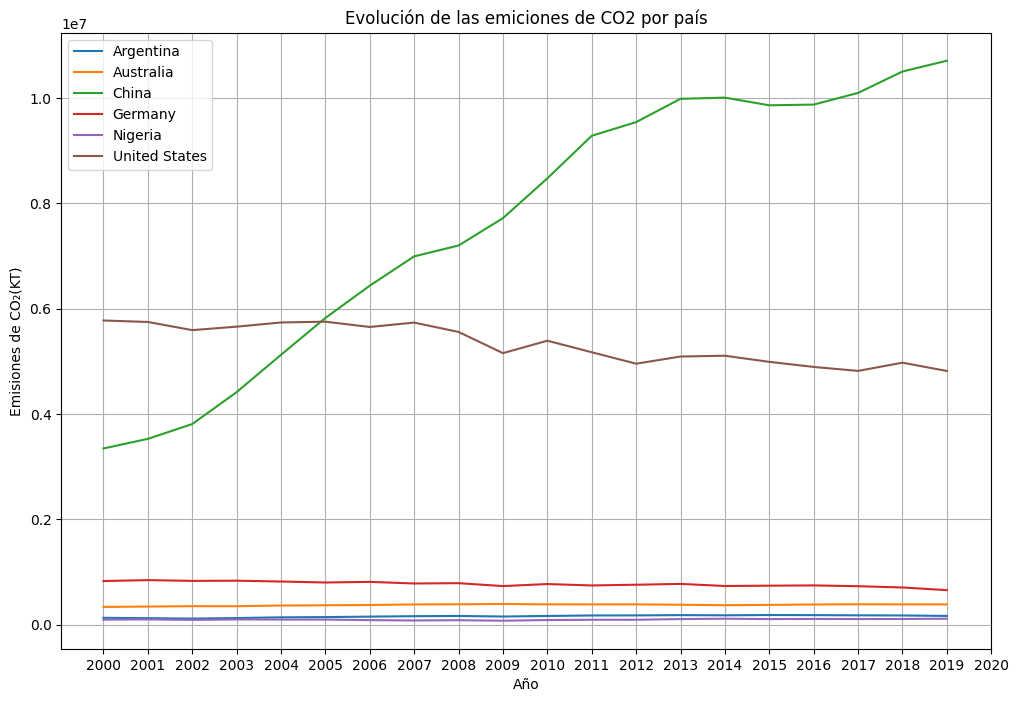

In [69]:
# emisiones de carbono por pais
plt.figure(figsize=(12, 8))
for country in paises['Entity'].unique():
    country_data = paises[paises['Entity'] == country]
    plt.plot(country_data['Year'], country_data['Value_co2_emissions_kt_by_country'], label=country)

plt.xlabel("Año")
plt.ylabel("Emisiones de CO₂(KT)")
plt.title("Evolución de las emiciones de CO2 por país")
plt.xticks(paises['Year'].unique())
plt.legend()
plt.grid(True)
plt.show()

Calcular las medidas de tendencia central para facilitar la comparación y visualizacion de distintas variables por país

In [70]:
#Pormedio de emisiones de carbono para 5 paises
agrupado0 = paises.groupby('Entity')['Value_co2_emissions_kt_by_country'].mean()
display("Emisiones de carbono", agrupado0)
#Promedio de Access to electricity (% of population) para 5 paises de (2000 - 2020)
agrupado1 = paises.groupby('Entity')['Access to electricity (% of population)'].mean()
display("Acceso a electricidad", agrupado1)
#Promedio de Renewable energy share in total final energy consumption (%) para 5 paises de (2000 - 2020)
agrupado2 = paises.groupby('Entity')['Renewable energy share in the total final energy consumption (%)'].mean()
display("Proporción de energía renovable del consumo total", agrupado2)
#Promedio de GDP per capita para 5 paises de (2000- 2020)
agrupado3 = paises.groupby('Entity')['gdp_per_capita'].mean()
display("PBI per capita", agrupado3)

'Emisiones de carbono'

,Value_co2_emissions_kt_by_country
Entity,
Argentina,1.604620e+05
Australia,3.755380e+05
China,7.636642e+06
Germany,7.736445e+05
Nigeria,9.896250e+04
United States,5.329539e+06


'Acceso a electricidad'

,Access to electricity (% of population)
Entity,
Argentina,98.241525
Australia,100.000000
China,99.076624
Germany,100.000000
Nigeria,51.191653
United States,100.000000


'Proporción de energía renovable del consumo total'

,Renewable energy share in the total final energy consumption (%)
Entity,
Argentina,9.5605
Australia,8.2665
China,16.4925
Germany,10.6920
Nigeria,84.1645
United States,7.5140


'PBI per capita'

,gdp_per_capita
Entity,
Argentina,9238.734894
Australia,45553.202580
China,5063.765297
Germany,39567.196973
Nigeria,1877.213468
United States,50076.813150


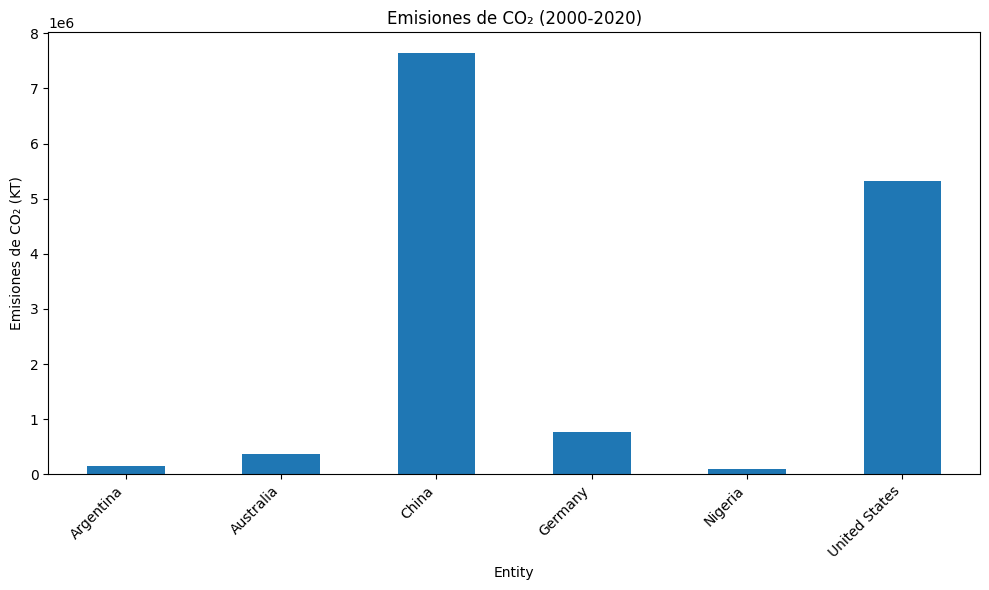

In [71]:
#Bar plot para emisiones de carbono por pais
agrupado0.plot(kind='bar', figsize=(10, 6), title='Emisiones de CO₂ (2000-2020)')
plt.ylabel('Emisiones de CO₂ (KT)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

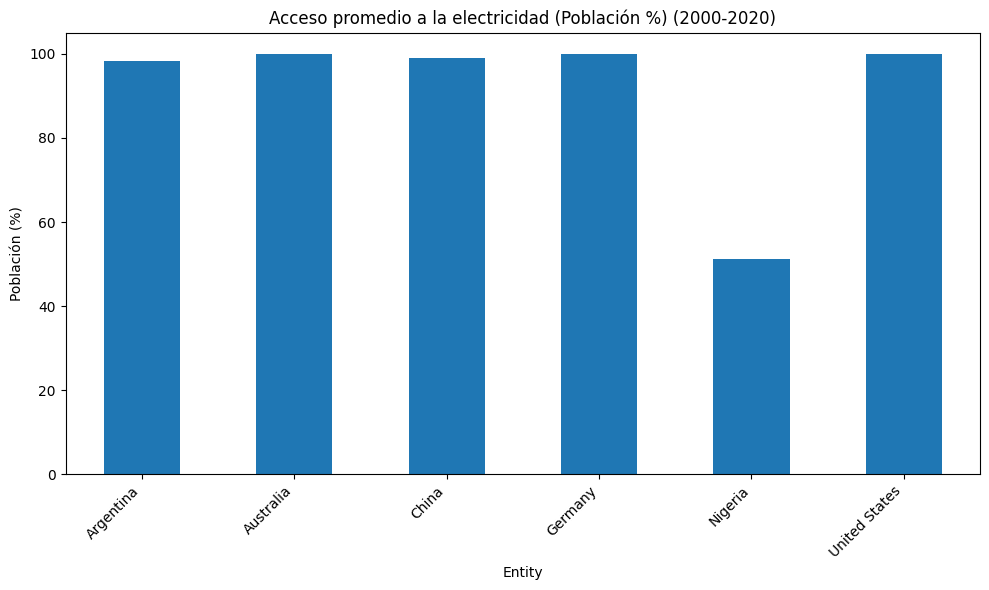

In [72]:
# Bar plot para acceso a electricidad
agrupado1.plot(kind='bar', figsize=(10, 6), title='Acceso promedio a la electricidad (Población %) (2000-2020)')
plt.ylabel('Población (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

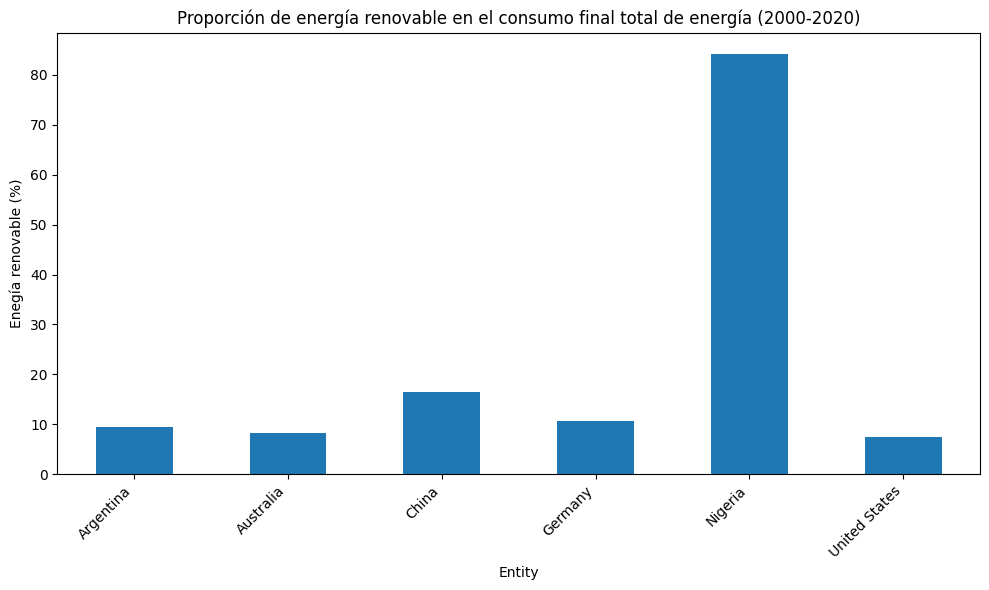

In [73]:
# Bar plot. Proporción de energía renovable en el consumo final total de energía
agrupado2.plot(kind='bar', figsize=(10, 6), title='Proporción de energía renovable en el consumo final total de energía (2000-2020)')
plt.ylabel('Enegía renovable (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

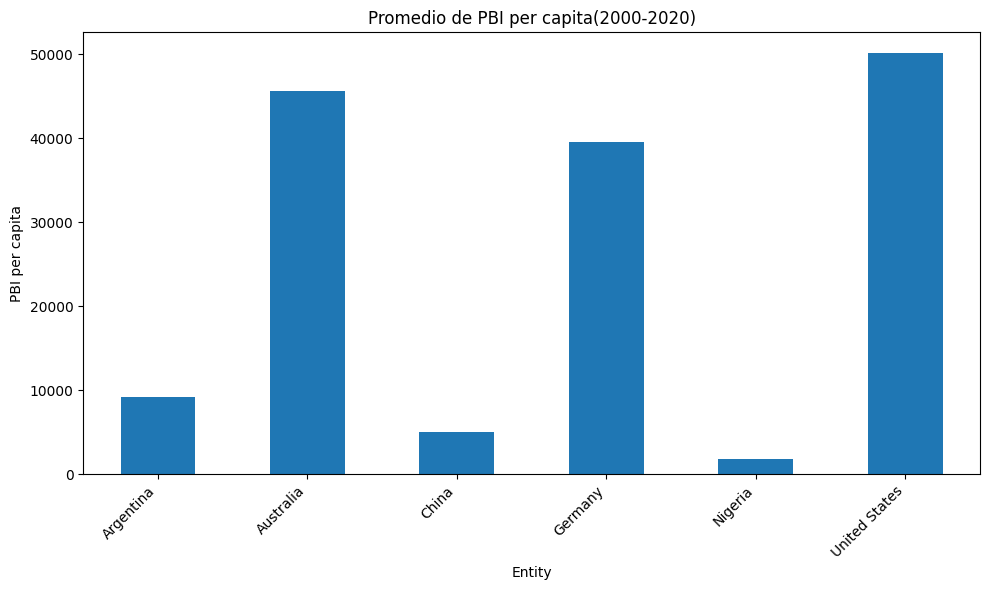

In [74]:
# Bar plot promedio GDP per capita
agrupado3.plot(kind='bar', figsize=(10, 6), title='Promedio de PBI per capita(2000-2020)')
plt.ylabel('PBI per capita')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Para continuar con la exploración de datos voy a eliminar algunas columnas con variables que no son de mi interés y rellenar los valores faltantes.

In [75]:
#Selección de variables de interés
col_selec = ["Entity", "Year",
     'Access to electricity (% of population)',
    'Renewable energy share in the total final energy consumption (%)',
    'Electricity from fossil fuels (TWh)',
    'Electricity from nuclear (TWh)',
    'Electricity from renewables (TWh)',
    'Low-carbon electricity (% electricity)',
    'Primary energy consumption per capita (kWh/person)',
    'Value_co2_emissions_kt_by_country',
    'Renewables (% equivalent primary energy)',
    'gdp_growth',
    'gdp_per_capita',
    'Land Area(Km2)'
]

# Crear nueco data.frame
df_selec = df[col_selec].copy()
display(df_selec)
print(df_selec.columns)
print(f' fila, columnas:', df_selec.shape)

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2)
0,Afghanistan,2000,1.613591,44.99,0.16,0.0,0.31,65.957440,302.59482,760.000000,NaN,NaN,NaN,652230.0
1,Afghanistan,2001,4.074574,45.60,0.09,0.0,0.50,84.745766,236.89185,730.000000,NaN,NaN,NaN,652230.0
2,Afghanistan,2002,9.409158,37.83,0.13,0.0,0.56,81.159424,210.86215,1029.999971,NaN,NaN,179.426579,652230.0
3,Afghanistan,2003,14.738506,36.66,0.31,0.0,0.63,67.021280,229.96822,1220.000029,NaN,8.832278,190.683814,652230.0
4,Afghanistan,2004,20.064968,44.24,0.33,0.0,0.56,62.921350,204.23125,1029.999971,NaN,1.414118,211.382074,652230.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,81.90,3.50,0.0,3.32,48.680350,3227.68020,11020.000460,NaN,0.755869,1464.588957,390757.0
3645,Zimbabwe,2017,44.178635,82.46,3.05,0.0,4.30,58.503407,3068.01150,10340.000150,NaN,4.709492,1235.189032,390757.0
3646,Zimbabwe,2018,45.572647,80.23,3.73,0.0,5.46,59.412407,3441.98580,12380.000110,NaN,4.824211,1254.642265,390757.0
3647,Zimbabwe,2019,46.781475,81.50,3.66,0.0,4.58,55.582527,3003.65530,11760.000230,NaN,-6.144236,1316.740657,390757.0


Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Land Area(Km2)'],
      dtype='object')
 fila, columnas: (3649, 14)


In [76]:
# Aplicar interpolación lineal. Útil para series de tiempo
df2 = df_selec.interpolate(method='linear', axis=0, limit_direction='both')

# Verificar que no hay datos nulos
print("\nNúmero de datos faltantes por columna:")
display(df2.isnull().sum())



Número de datos faltantes por columna:


/tmp/ipython-input-2762386019.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df2 = df_selec.interpolate(method='linear', axis=0, limit_direction='both')


,0
Entity,0
Year,0
Access to electricity (% of population),0
Renewable energy share in the total final energy consumption (%),0
Electricity from fossil fuels (TWh),0
Electricity from nuclear (TWh),0
Electricity from renewables (TWh),0
Low-carbon electricity (% electricity),0
Primary energy consumption per capita (kWh/person),0
Value_co2_emissions_kt_by_country,0


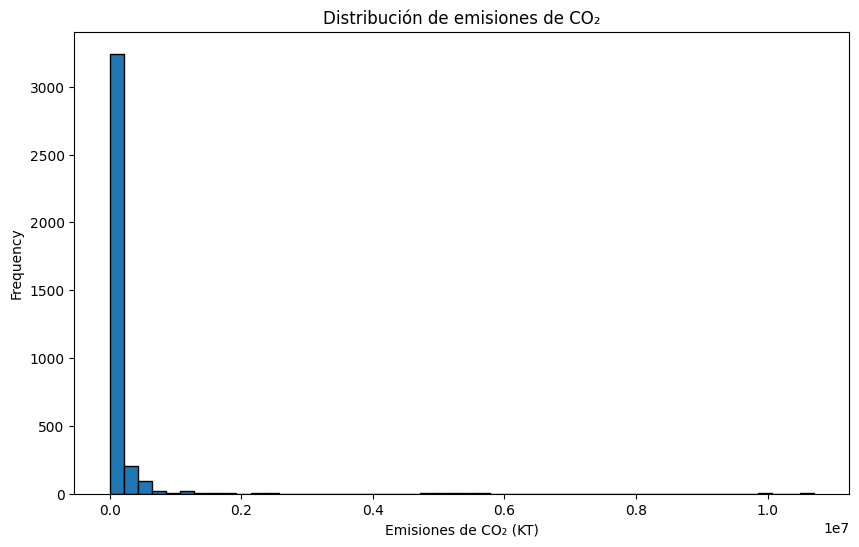

In [77]:
# Emisiones de carbono sin diferencias por paises
plt.figure(figsize=(10, 6))
plt.hist(df2['Value_co2_emissions_kt_by_country'], bins=50, edgecolor='black')
plt.xlabel("Emisiones de CO₂ (KT)")
plt.ylabel("Frequency")
plt.title("Distribución de emisiones de CO₂")
plt.show()
plt.show()

Este histograma muestra la distribución de las emisiones de CO2 para todas las obervaciones, es decir para todos los paises y todos los años. Los datos están muy sesgados hacia la derecha. Esto significa que la mayoría de los países tienen emisiones de CO2 relativamente bajas, mientras que un pequeño número de países tienen emisiones muy altas. Esta asimetría dificulta ver los detalles de la distribución para la mayoría de los países. Una opción para mejorar el análisis es transformar la varible a una escala logarítmica.

In [78]:
# lista de variables de interés
electricity_cols = ['Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)']

# nuevo dataframe
df_electricidad = paises[electricity_cols]

print("\ncolumanas de electricidad por paises filtrados:")
display(df_electricidad)


columanas de electricidad por paises filtrados:


,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh)
105,50.37,5.99,28.89
106,42.91,6.54,37.04
107,39.70,5.39,36.06
108,46.73,7.03,34.38
109,57.35,7.31,31.03
...,...,...,...
3518,2656.96,805.69,624.91
3519,2540.17,804.95,707.19
3520,2661.30,807.08,733.17
3521,2588.21,809.41,760.76


In [79]:
#Calcular media y desvío estándar
mean_electricity = paises.groupby('Entity')[electricity_cols].mean()
std_electricity = paises.groupby('Entity')[electricity_cols].std()

print("\nDistintos tipos de Electricidad promedio por pais (2000-2020):")
display(mean_electricity)

print("\nDesvío estandar (2000-2020):")
display(std_electricity)


Distintos tipos de Electricidad promedio por pais (2000-2020):


,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh)
Entity,,,
Argentina,76.309524,6.722857,33.811429
Australia,201.980476,0.000000,28.881905
China,3234.634762,124.247143,938.235238
Germany,363.829048,123.940476,125.419048
Nigeria,18.243333,0.000000,6.637143
United States,2745.333333,790.600476,487.338095



Desvío estandar (2000-2020):


,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh)
Entity,,,
Argentina,20.062581,1.077368,2.438881
Australia,9.102253,0.000000,13.146367
China,1366.406577,107.901467,623.718791
Germany,35.804427,38.469717,70.888854
Nigeria,5.446514,0.000000,1.198166
United States,131.825602,16.086573,160.884120


In [80]:
# Combinar mean y std en un solo dataframe
electricity = pd.concat([mean_electricity, std_electricity], keys=['Mean', 'Standard Deviation'], axis=1)

# Transponer el DataFrame, paises como columnas y electricidad como filas
# electricity_summary = electricity_summary.T

print("\nCombined electricity summary data for plotting:")
display(electricity)


Combined electricity summary data for plotting:


Mean  \
              Electricity from fossil fuels (TWh)   
Entity                                              
Argentina                               76.309524   
Australia                              201.980476   
China                                 3234.634762   
Germany                                363.829048   
Nigeria                                 18.243333   
United States                         2745.333333   

                                              \
              Electricity from nuclear (TWh)   
Entity                                         
Argentina                           6.722857   
Australia                           0.000000   
China                             124.247143   
Germany                           123.940476   
Nigeria                             0.000000   
United States                     790.600476   

                                                 \
              Electricity from renewables (TWh)   
Entity                                            
Argentina                             33.811429   
Australia                             28.881905   
China                                938.235238   
Germany                              125.419048   
Nigeria                                6.637143   
United States                        487.338095   

                               Standard Deviation  \
              Electricity from fossil fuels (TWh)   
Entity                                              
Argentina                               20.062581   
Australia                                9.102253   
China                                 1366.406577   
Germany                                 35.804427   
Nigeria                                  5.446514   
United States                          131.825602   

                                                                                
              Electricity from nuclear (TWh) Electricity from renewables (TWh)  
Entity                                                                          
Argentina                           1.077368                          2.438881  
Australia                           0.000000                         13.146367  
China                             107.901467                        623.718791  
Germany                            38.469717                         70.888854  
Nigeria                             0.000000                          1.198166  
United States                      16.086573                        160.884120

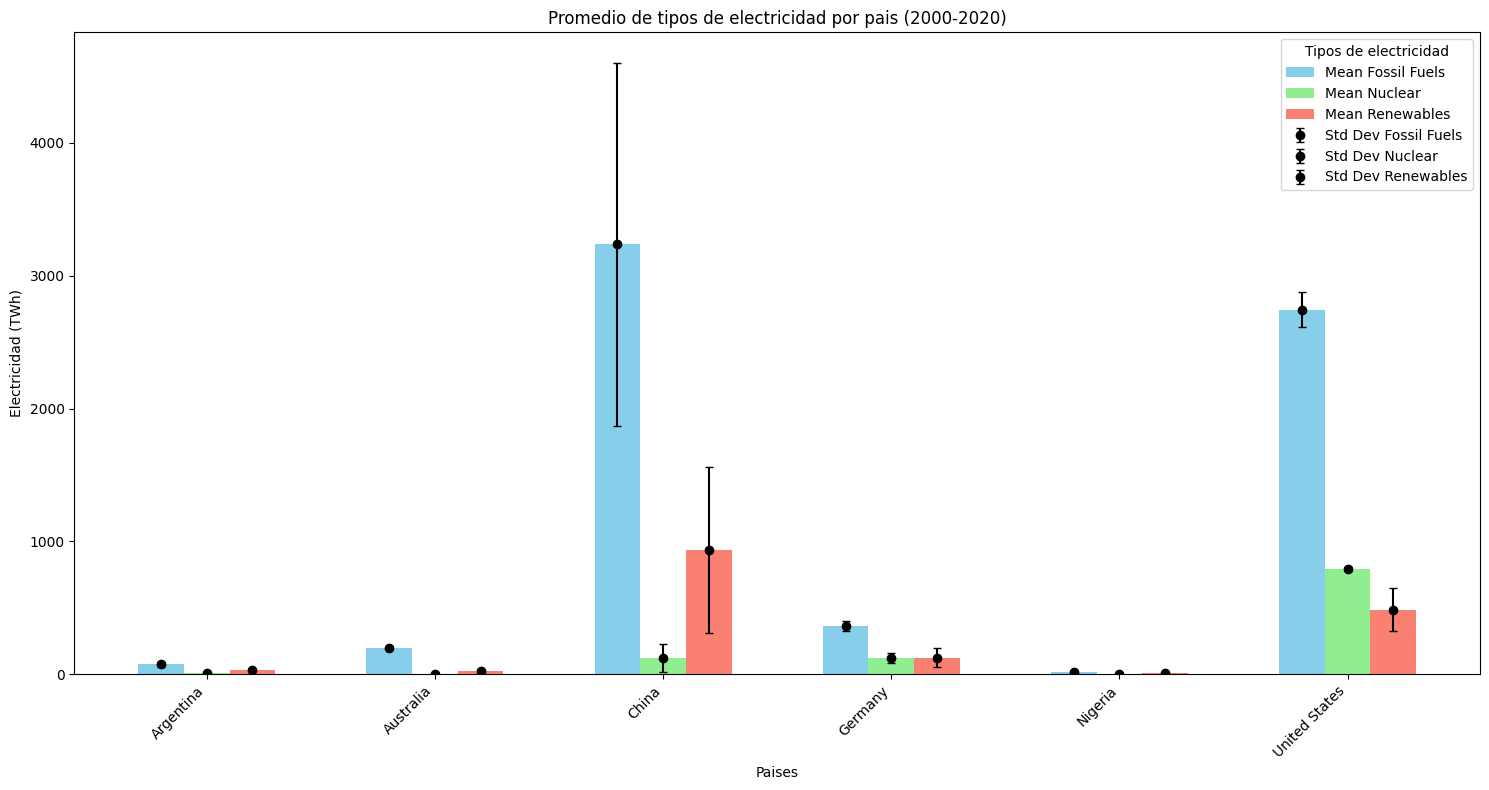

In [81]:
fig, ax = plt.subplots(figsize=(15, 8))

bar_width = 0.2

# Extraer index
paises2 = electricity.index
x = np.arange(len(paises2))

# Grafico de barras par cada tipo de electricidad, media y desvío estandar
ax.bar(x - bar_width, electricity['Mean']['Electricity from fossil fuels (TWh)'], bar_width, label='Mean Fossil Fuels', color='skyblue')
ax.bar(x, electricity['Mean']['Electricity from nuclear (TWh)'], bar_width, label='Mean Nuclear', color='lightgreen')
ax.bar(x + bar_width, electricity['Mean']['Electricity from renewables (TWh)'], bar_width, label='Mean Renewables', color='salmon')

# Add error bars for standard deviation
ax.errorbar(x - bar_width, electricity['Mean']['Electricity from fossil fuels (TWh)'], yerr=electricity['Standard Deviation']['Electricity from fossil fuels (TWh)'], fmt='o', color='black', capsize=3, label='Std Dev Fossil Fuels')
ax.errorbar(x, electricity['Mean']['Electricity from nuclear (TWh)'], yerr=electricity['Standard Deviation']['Electricity from nuclear (TWh)'], fmt='o', color='black', capsize=3, label='Std Dev Nuclear')
ax.errorbar(x + bar_width, electricity['Mean']['Electricity from renewables (TWh)'], yerr=electricity['Standard Deviation']['Electricity from renewables (TWh)'], fmt='o', color='black', capsize=3, label='Std Dev Renewables')


ax.set_xlabel("Paises")
ax.set_ylabel("Electricidad (TWh)")
ax.set_title("Promedio de tipos de electricidad por pais (2000-2020)")
ax.set_xticks(x)
ax.set_xticklabels(paises2, rotation=45, ha='right')
ax.legend(title="Tipos de electricidad")
plt.tight_layout()
plt.show()

Gráficos de boxplot, para seguir explorando la distribución de las variables y presencia de outliers.

Transformar la variable CO2 Emissions para mejorar su visualización e interpretación



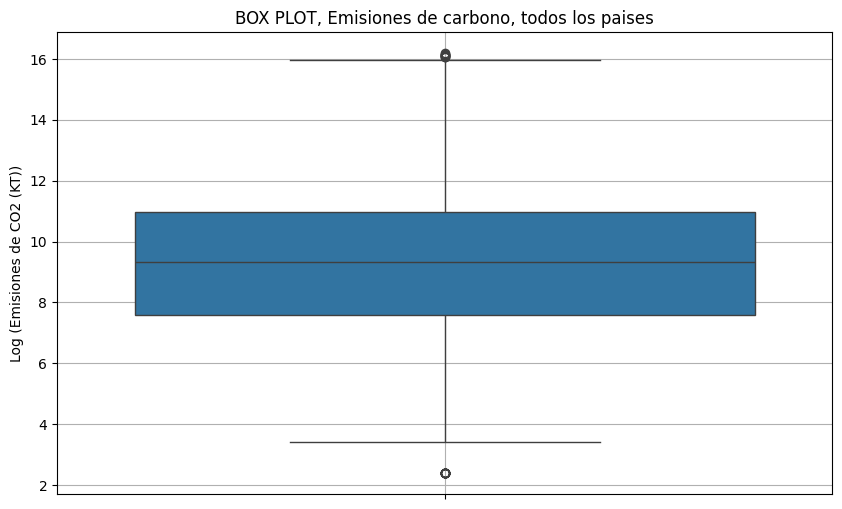

In [82]:
# Aplicar tranformación logaritmica a variables co2
df2['Value_co2_emissions_kt_by_country_log'] = np.log1p(df2['Value_co2_emissions_kt_by_country']) #va agregar una nueva columna al data.frame df2

#Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df2['Value_co2_emissions_kt_by_country_log'])
plt.ylabel("Log (Emisiones de CO2 (KT))")
plt.title("BOX PLOT, Emisiones de carbono, todos los paises")
plt.grid(True)
plt.show()

En comparación con los datos originales de emisiones de CO2 que mostraban un sesgo hacia la derecha, es decir pocos paises con mucha emsisión, el boxplot con los datos transformados logarítmicamente nos permite ver mejor la distribución de las emisiones de la mayoría de los países e identificar más claramente los outliers.

Creamos un nuevo subset de datos a partir de los datos sin valores nulos, las variables seleccionadas y 6 paises, uno de cada continente.

In [83]:
#Seleccionar paises para analizar
paises2 = ['China', 'Nigeria', 'Germany', 'United States', 'Argentina', 'Australia']
print("Paises seleccionados:", paises2)

Paises seleccionados: ['China', 'Nigeria', 'Germany', 'United States', 'Argentina', 'Australia']


In [84]:
# Filtrar el dataset
df_filtrado = df2[df2['Entity'].isin(paises2)].copy()
print("\nData filtrada:")
display(df_filtrado)


Data filtrada:


,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Value_co2_emissions_kt_by_country_log
105,Argentina,2000,95.783290,9.850,50.37,5.99,28.89,40.914955,18849.810,1.322700e+05,12.283858,-0.788999,7708.099115,2780400.0,11.792608
106,Argentina,2001,95.511060,11.510,42.91,6.54,37.04,50.387330,18210.120,1.252600e+05,15.937488,-4.408840,7208.373114,2780400.0,11.738155
107,Argentina,2002,96.228870,11.620,39.70,5.39,36.06,51.078250,17275.256,1.174700e+05,16.249306,-10.894485,2593.404563,2780400.0,11.673947
108,Argentina,2003,96.442635,10.820,46.73,7.03,34.38,46.982075,18326.521,1.276600e+05,14.408259,8.837041,3349.806300,2780400.0,11.757134
109,Argentina,2004,96.653500,9.290,57.35,7.31,31.03,40.066883,19261.457,1.413800e+05,12.185576,9.029573,4277.721573,2780400.0,11.859214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3518,United States,2016,100.000000,9.460,2656.96,805.69,624.91,34.998875,78613.540,4.894500e+06,8.285086,1.711427,58021.400500,9833517.0,15.403623
3519,United States,2017,100.000000,9.920,2540.17,804.95,707.19,37.315506,78289.010,4.819370e+06,9.082049,2.332679,60109.655730,9833517.0,15.388154
3520,United States,2018,100.000000,10.120,2661.30,807.08,733.17,36.659092,80583.340,4.975310e+06,8.964939,2.996464,63064.418410,9833517.0,15.419998
3521,United States,2019,100.000000,10.420,2588.21,809.41,760.76,37.759180,79489.016,4.817720e+06,9.315263,2.161177,65279.529030,9833517.0,15.387812


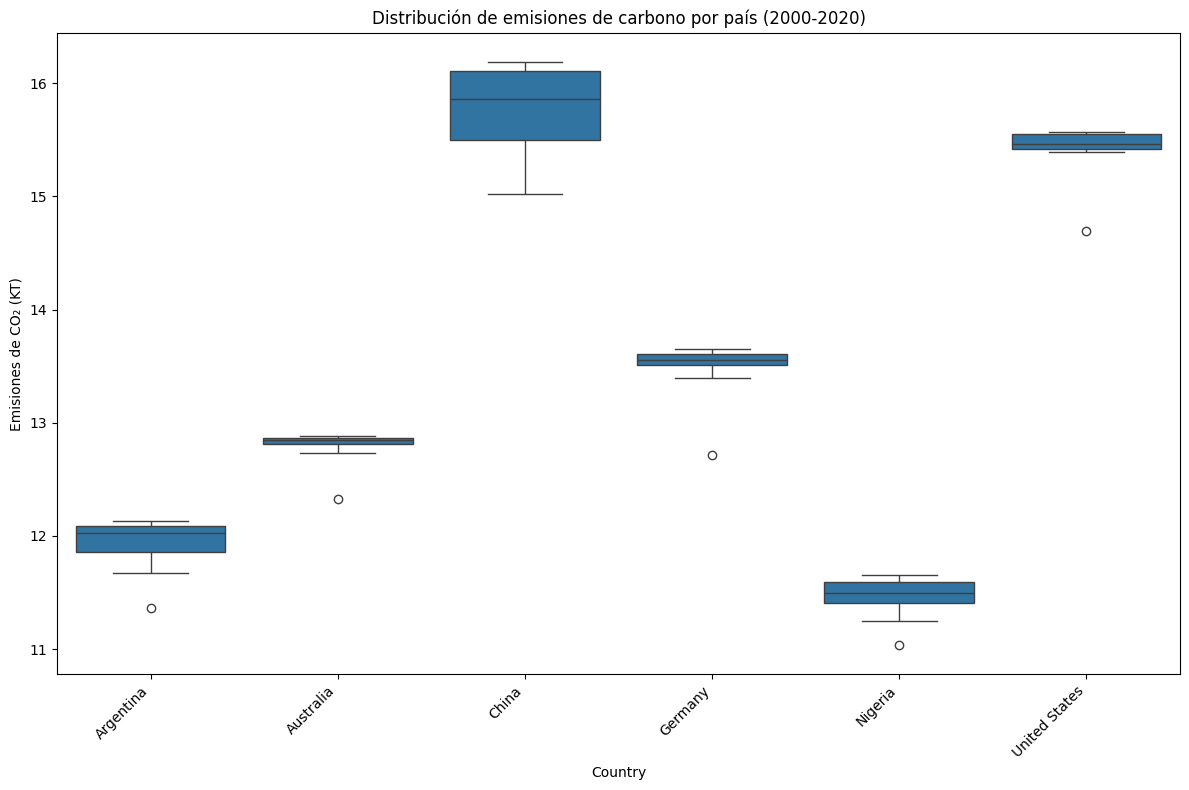

In [85]:
#Probar boxplots
plt.figure(figsize=(12, 8))
sns.boxplot(x='Entity', y='Value_co2_emissions_kt_by_country_log', data=df_filtrado)
plt.xlabel("Country")
plt.ylabel("Emisiones de CO₂ (KT)")
plt.title("Distribución de emisiones de carbono por país (2000-2020)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Se pueden observar diferencias significativas entre los paises de distintos continentes en relación a las emisiones de carbono.

**Análisis de correlaciones**

Con el análisis de correlación podré realizar una primera aporximación para explorar asociaciones y patrones entre variables.




In [86]:
##Estandarizar datos
# Excluir Entity y year del análisis
df_num = df2.drop(['Entity', 'Year'], axis=1)

scaler = StandardScaler()
df_stand1 = scaler.fit_transform(df_num)
df_stand2 = pd.DataFrame(df_stand1, columns=df_num.columns)

print("\nDatos estandarizados:")
display(df_stand2)


Datos estandarizados:


,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Value_co2_emissions_kt_by_country_log
0,-2.542935,0.423058,-0.201302,-0.18341,-0.225914,0.846378,-0.731738,-0.201689,-0.958721,1.008659,-0.663171,0.012028,-1.097315
1,-2.461859,0.443722,-0.201504,-0.18341,-0.224089,1.394741,-0.733627,-0.201730,-0.958721,1.008659,-0.663171,0.012028,-1.113967
2,-2.286114,0.180518,-0.201388,-0.18341,-0.223513,1.290068,-0.734376,-0.201323,-0.958721,1.008659,-0.663171,0.012028,-0.971592
3,-2.110541,0.140885,-0.200870,-0.18341,-0.222841,0.877427,-0.733826,-0.201065,-0.958721,1.008659,-0.662590,0.012028,-0.901562
4,-1.935064,0.397653,-0.200812,-0.18341,-0.223513,0.757765,-0.734567,-0.201323,-0.958721,-0.317167,-0.661520,0.012028,-0.971592
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,-1.193919,1.673361,-0.191677,-0.18341,-0.197008,0.342122,-0.647607,-0.187761,-0.759653,-0.434814,-0.596761,-0.152930,0.009372
3645,-1.140651,1.692330,-0.192974,-0.18341,-0.187597,0.628821,-0.652200,-0.188684,-0.759653,0.271806,-0.608615,-0.152930,-0.016997
3646,-1.094726,1.616791,-0.191015,-0.18341,-0.176457,0.655352,-0.641443,-0.185915,-0.759653,0.292309,-0.607610,-0.152930,0.057549
3647,-1.054902,1.659811,-0.191216,-0.18341,-0.184908,0.543571,-0.654051,-0.186756,-0.759653,-1.668049,-0.604401,-0.152930,0.036278


In [87]:
#calculamos matriz de correlación
cor = df_stand2.corr()
print("\nCorrelation Matrix:")
display(cor)


Correlation Matrix:


,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Value_co2_emissions_kt_by_country_log
Access to electricity (% of population),1.000000,-0.778296,0.123623,0.125019,0.137555,-0.141319,0.455854,0.121454,0.013612,-0.110009,0.414232,0.056222,0.454985
Renewable energy share in the total final energy consumption (%),-0.778296,1.000000,-0.129321,-0.126783,-0.065255,0.440349,-0.422330,-0.120821,0.249919,0.100194,-0.347172,-0.044356,-0.378942
Electricity from fossil fuels (TWh),0.123623,-0.129321,1.000000,0.645081,0.845094,-0.064419,0.106092,0.975425,-0.066942,0.026400,0.108281,0.627739,0.404251
Electricity from nuclear (TWh),0.125019,-0.126783,0.645081,1.000000,0.492236,0.072273,0.177075,0.597494,-0.037425,-0.041102,0.231666,0.466896,0.342815
Electricity from renewables (TWh),0.137555,-0.065255,0.845094,0.492236,1.000000,0.090006,0.120501,0.829181,0.129933,0.006166,0.140368,0.704972,0.384609
Low-carbon electricity (% electricity),-0.141319,0.440349,-0.064419,0.072273,0.090006,1.000000,-0.118417,-0.045981,0.370970,0.001247,0.043979,0.042822,-0.026013
Primary energy consumption per capita (kWh/person),0.455854,-0.422330,0.106092,0.177075,0.120501,-0.118417,1.000000,0.098121,0.071823,-0.030014,0.667371,0.114670,0.347888
Value_co2_emissions_kt_by_country,0.121454,-0.120821,0.975425,0.597494,0.829181,-0.045981,0.098121,1.000000,-0.051355,0.036628,0.095534,0.645048,0.408610
Renewables (% equivalent primary energy),0.013612,0.249919,-0.066942,-0.037425,0.129933,0.370970,0.071823,-0.051355,1.000000,-0.050762,0.218710,0.071812,-0.071662
gdp_growth,-0.110009,0.100194,0.026400,-0.041102,0.006166,0.001247,-0.030014,0.036628,-0.050762,1.000000,-0.123104,0.032414,-0.021850


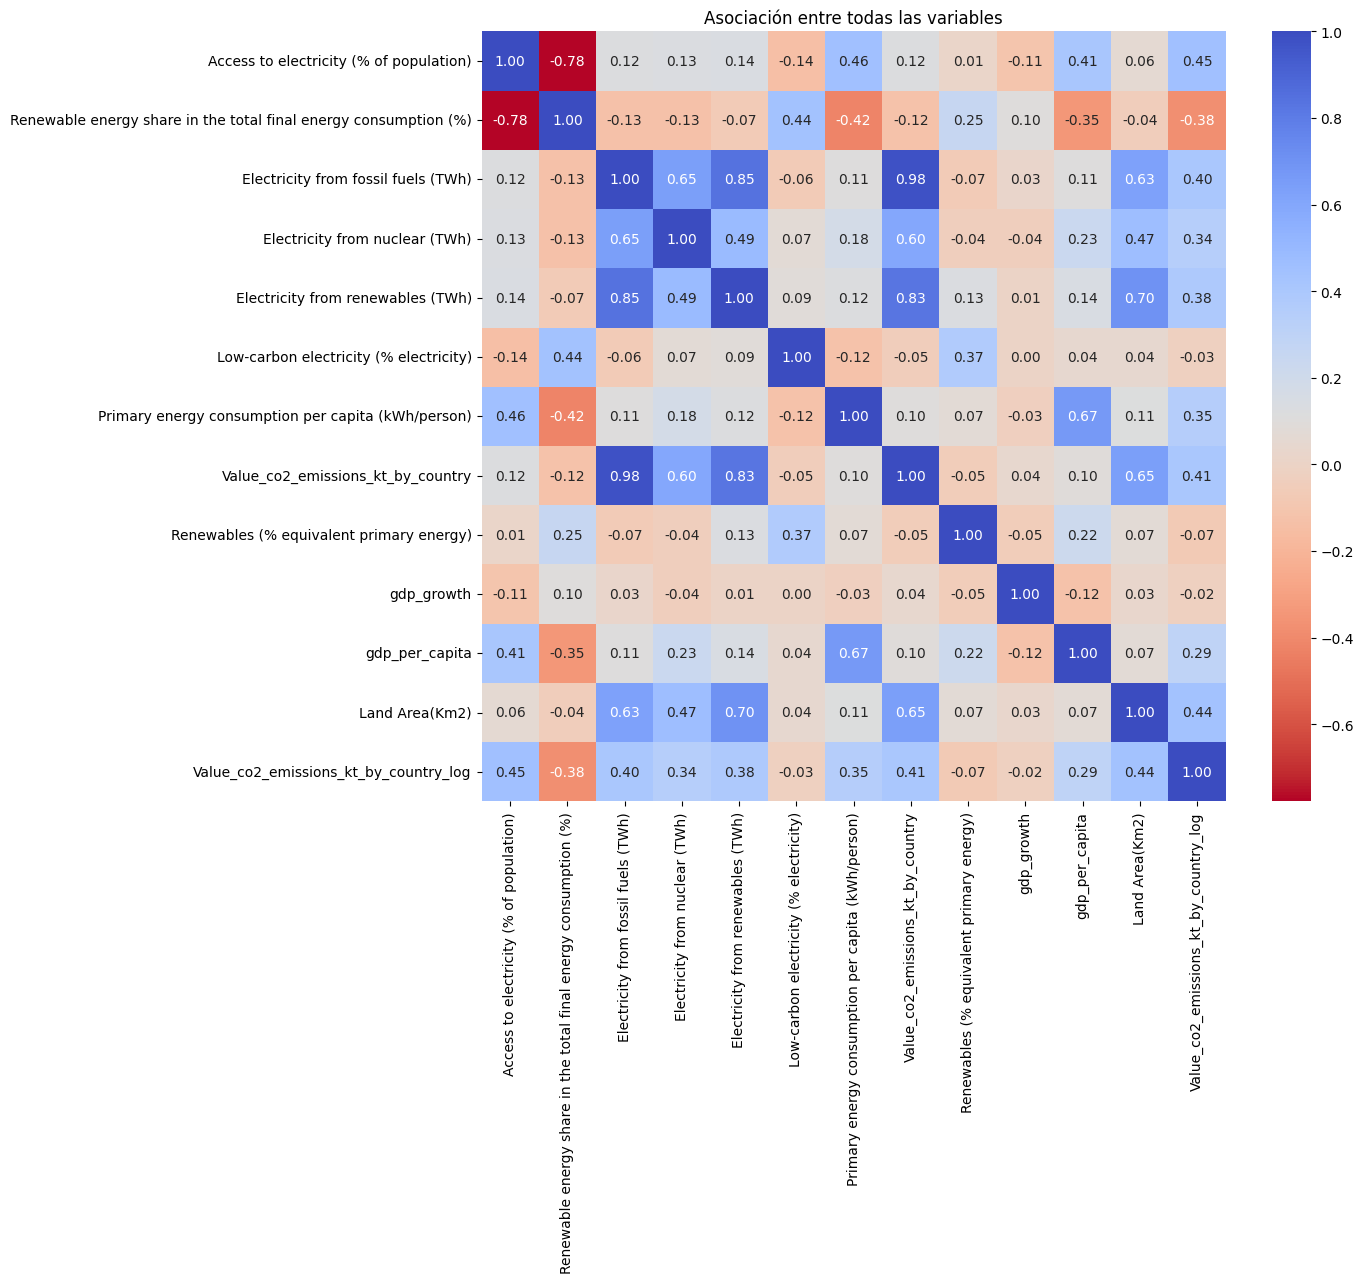

In [88]:
## Creación del heatmap para visualizar las correlaciones
# Tamaño del plot
plt.figure(figsize=(12, 10))

# heatmap
sns.heatmap(cor, annot=True, cmap='coolwarm_r', fmt=".2f") ## rojo cor negativas, blancas neutras, azules positivas
plt.title("Asociación entre todas las variables")
plt.show()

Ejemplos de correlaciones positivas significativas:

-Electricity from fossil fuels (TWh) vs. 	Value_co2_emissions_kt_by_country	(0.98)
-Land area(Km2) vs. Electricity from renewables (0.70)

Ejemplos de correlaciones negativas significativas

-Access to electricity (% of population) vs. Renewable energy share in the total final energy consumption (%)	(-0.78)

Algunas observaciones:

La fuerte correlación positiva entre la electricidad a partir de combustibles fósiles y las emisiones de CO2 resalta el impacto ambiental de los combustibles fósiles.

La fuerte correlación negativa entre el acceso a la electricidad la participación de la energía renovable en el cosumo final de energía podría indicar que los países con mayor acceso a electricidad dependen en gran medida de fuentes de energía tradicionales o menos limpias.





**EDA : resultados y conclusiones preliminares**

Se observaron notables diferencias entre los países seleccionados al considerar variables socioeconómicas como el acceso a la electricidad, el PBI per cápita o el nivel promedio de emisiones de carbono. Asimismo, se identificaron contrastes en relación con sus matrices energéticas, especialmente en la diversidad de fuentes empleadas para la generación de electricidad.





# **Segunda parte**
- Preparación del dataset : renombrar variables de interés

**Anaisis para el año 2020**
- Feature selection: PCA
- Algoritmo de clasificación : K-means
- Validación del modelo

**Anaisis para el año 2000**
- Feature selection: PCA
- Algoritmo de clasificación : K-means
- Validación del modelo



- **Conclusiones**


# Preparación del dataset : renombrar variables de interés

In [89]:
display(df2)
df2.info()
print(df2.columns)

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Value_co2_emissions_kt_by_country_log
0,Afghanistan,2000,1.613591,44.99,0.16,0.0,0.31,65.957440,302.59482,760.000000,0.053235,8.832278,179.426579,652230.0,6.634633
1,Afghanistan,2001,4.074574,45.60,0.09,0.0,0.50,84.745766,236.89185,730.000000,0.053235,8.832278,179.426579,652230.0,6.594413
2,Afghanistan,2002,9.409158,37.83,0.13,0.0,0.56,81.159424,210.86215,1029.999971,0.053235,8.832278,179.426579,652230.0,6.938284
3,Afghanistan,2003,14.738506,36.66,0.31,0.0,0.63,67.021280,229.96822,1220.000029,0.053235,8.832278,190.683814,652230.0,7.107425
4,Afghanistan,2004,20.064968,44.24,0.33,0.0,0.56,62.921350,204.23125,1029.999971,0.053235,1.414118,211.382074,652230.0,6.938284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,81.90,3.50,0.0,3.32,48.680350,3227.68020,11020.000460,2.523421,0.755869,1464.588957,390757.0,9.307558
3645,Zimbabwe,2017,44.178635,82.46,3.05,0.0,4.30,58.503407,3068.01150,10340.000150,2.523421,4.709492,1235.189032,390757.0,9.243872
3646,Zimbabwe,2018,45.572647,80.23,3.73,0.0,5.46,59.412407,3441.98580,12380.000110,2.523421,4.824211,1254.642265,390757.0,9.423918
3647,Zimbabwe,2019,46.781475,81.50,3.66,0.0,4.58,55.582527,3003.65530,11760.000230,2.523421,-6.144236,1316.740657,390757.0,9.372544


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 15 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3649 non-null   float64
 3   Renewable energy share in the total final energy consumption (%)  3649 non-null   float64
 4   Electricity from fossil fuels (TWh)                               3649 non-null   float64
 5   Electricity from nuclear (TWh)                                    3649 non-null   float64
 6   Electricity from renewables (TWh)                                 3649 non-null   float64
 7   Low-carbon electricity (% electri

En función de mi objetivo de “identificar patrones y perfiles energéticos entre países a partir de un conjunto reducido de variables clave que integren indicadores energéticos, socioeconómicos y ambientales”, incluí una combinación de indicadores que abarcan estos tres aspectos:

Indicadores energéticos: acceso a la electricidad, generación de electricidad a partir de distintas fuentes (combustibles fósiles, nuclear y renovables), porcentaje de electricidad de bajas emisiones de carbono y proporción de renovables.

Indicadores socioeconómicos: PBI per cápita.

Indicadores ambientales: emisiones de CO₂.

In [90]:
##Selecciono variables de interés y creo nuevo dataframe
df3 = df2.drop(['Value_co2_emissions_kt_by_country_log','Renewable energy share in the total final energy consumption (%)', 'Primary energy consumption per capita (kWh/person)', 'gdp_growth', 'Land Area(Km2)'], axis=1).copy()
display(df3)
df3.info()



,Entity,Year,Access to electricity (% of population),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_per_capita
0,Afghanistan,2000,1.613591,0.16,0.0,0.31,65.957440,760.000000,0.053235,179.426579
1,Afghanistan,2001,4.074574,0.09,0.0,0.50,84.745766,730.000000,0.053235,179.426579
2,Afghanistan,2002,9.409158,0.13,0.0,0.56,81.159424,1029.999971,0.053235,179.426579
3,Afghanistan,2003,14.738506,0.31,0.0,0.63,67.021280,1220.000029,0.053235,190.683814
4,Afghanistan,2004,20.064968,0.33,0.0,0.56,62.921350,1029.999971,0.053235,211.382074
...,...,...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,3.50,0.0,3.32,48.680350,11020.000460,2.523421,1464.588957
3645,Zimbabwe,2017,44.178635,3.05,0.0,4.30,58.503407,10340.000150,2.523421,1235.189032
3646,Zimbabwe,2018,45.572647,3.73,0.0,5.46,59.412407,12380.000110,2.523421,1254.642265
3647,Zimbabwe,2019,46.781475,3.66,0.0,4.58,55.582527,11760.000230,2.523421,1316.740657


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Entity                                    3649 non-null   object 
 1   Year                                      3649 non-null   int64  
 2   Access to electricity (% of population)   3649 non-null   float64
 3   Electricity from fossil fuels (TWh)       3649 non-null   float64
 4   Electricity from nuclear (TWh)            3649 non-null   float64
 5   Electricity from renewables (TWh)         3649 non-null   float64
 6   Low-carbon electricity (% electricity)    3649 non-null   float64
 7   Value_co2_emissions_kt_by_country         3649 non-null   float64
 8   Renewables (% equivalent primary energy)  3649 non-null   float64
 9   gdp_per_capita                            3649 non-null   float64
dtypes: float64(8), int64(1), object(1)
m

In [91]:
##Renombrar columnas
df3 = df3.rename(columns={
    'Access to electricity (% of population)' :  "Access_electricity",
    'Electricity from fossil fuels (TWh)' : "Electricity_fossil_fuels",
    'Electricity from nuclear (TWh)' : "Electricity_nuclear",
    'Electricity from renewables (TWh)' : "Electricity_renewables",
    'Low-carbon electricity (% electricity)' : "Low_carbon_electricity",
    'Value_co2_emissions_kt_by_country' : "co2_emissions_kt",
    'Renewables (% equivalent primary energy)' : "Renewables_prop",
    'gdp_per_capita' : "gdp_per_capita"
})

df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    3649 non-null   object 
 1   Year                      3649 non-null   int64  
 2   Access_electricity        3649 non-null   float64
 3   Electricity_fossil_fuels  3649 non-null   float64
 4   Electricity_nuclear       3649 non-null   float64
 5   Electricity_renewables    3649 non-null   float64
 6   Low_carbon_electricity    3649 non-null   float64
 7   co2_emissions_kt          3649 non-null   float64
 8   Renewables_prop           3649 non-null   float64
 9   gdp_per_capita            3649 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 285.2+ KB


In [92]:
display(df3)

,Entity,Year,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita
0,Afghanistan,2000,1.613591,0.16,0.0,0.31,65.957440,760.000000,0.053235,179.426579
1,Afghanistan,2001,4.074574,0.09,0.0,0.50,84.745766,730.000000,0.053235,179.426579
2,Afghanistan,2002,9.409158,0.13,0.0,0.56,81.159424,1029.999971,0.053235,179.426579
3,Afghanistan,2003,14.738506,0.31,0.0,0.63,67.021280,1220.000029,0.053235,190.683814
4,Afghanistan,2004,20.064968,0.33,0.0,0.56,62.921350,1029.999971,0.053235,211.382074
...,...,...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,3.50,0.0,3.32,48.680350,11020.000460,2.523421,1464.588957
3645,Zimbabwe,2017,44.178635,3.05,0.0,4.30,58.503407,10340.000150,2.523421,1235.189032
3646,Zimbabwe,2018,45.572647,3.73,0.0,5.46,59.412407,12380.000110,2.523421,1254.642265
3647,Zimbabwe,2019,46.781475,3.66,0.0,4.58,55.582527,11760.000230,2.523421,1316.740657


# **Feature selection - PCA**


In [93]:
## Primero estandarizamos los datos
# Exluir del análisis Entity y year
df3_num = df3.select_dtypes(exclude=['object', 'int64'])

# Generar el standarizador y aplicar a los datos numéricos
scaler = StandardScaler()
df3_ss = scaler.fit_transform(df3_num)

# Crear nuevo df con los datos estandarizados y manteniendo el index original
df3_stand = pd.DataFrame(df3_ss, columns=df3_num.columns, index=df3.index)

# Unir 'Entity', 'Year', y los datos standarizados
df4 = df3[['Entity', 'Year']].join(df3_stand)

display(df4.head())
display(df4.info())

,Entity,Year,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita
0,Afghanistan,2000,-2.542935,-0.201302,-0.18341,-0.225914,0.846378,-0.201689,-0.958721,-0.663171
1,Afghanistan,2001,-2.461859,-0.201504,-0.18341,-0.224089,1.394741,-0.201730,-0.958721,-0.663171
2,Afghanistan,2002,-2.286114,-0.201388,-0.18341,-0.223513,1.290068,-0.201323,-0.958721,-0.663171
3,Afghanistan,2003,-2.110541,-0.200870,-0.18341,-0.222841,0.877427,-0.201065,-0.958721,-0.662590
4,Afghanistan,2004,-1.935064,-0.200812,-0.18341,-0.223513,0.757765,-0.201323,-0.958721,-0.661520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    3649 non-null   object 
 1   Year                      3649 non-null   int64  
 2   Access_electricity        3649 non-null   float64
 3   Electricity_fossil_fuels  3649 non-null   float64
 4   Electricity_nuclear       3649 non-null   float64
 5   Electricity_renewables    3649 non-null   float64
 6   Low_carbon_electricity    3649 non-null   float64
 7   co2_emissions_kt          3649 non-null   float64
 8   Renewables_prop           3649 non-null   float64
 9   gdp_per_capita            3649 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 285.2+ KB


None

In [94]:
# Seleccionar unicamente las variables numericas
numeric_var = df4.select_dtypes(exclude=['object', 'int64'])

# calcular la media de las var estadarizadas
mean_ss = numeric_var.mean()

# calcular desvío estandar
std_ss = numeric_var.std()

print("Media:")
display(mean_ss)

print("\nDesvio estandar:")
display(std_ss)

Media:


,0
Access_electricity,3.154506e-16
Electricity_fossil_fuels,-5.841678e-18
Electricity_nuclear,1.947226e-17
Electricity_renewables,0.000000e+00
Low_carbon_electricity,-5.062787e-17
co2_emissions_kt,-7.788904e-18
Renewables_prop,1.869337e-16
gdp_per_capita,2.920839e-17



Desvio estandar:


,0
Access_electricity,1.000137
Electricity_fossil_fuels,1.000137
Electricity_nuclear,1.000137
Electricity_renewables,1.000137
Low_carbon_electricity,1.000137
co2_emissions_kt,1.000137
Renewables_prop,1.000137
gdp_per_capita,1.000137


Corroboramos la correcta estandarización a partir de observar la media muy cercana a 0 y el desvío estándar cercano a 1


Para avanzar en el análisis de los datos y en función de mi objetivo propuesto, trabajaré con dos años específicos: 2000 y 2020. Esta comparación permitirá observar cómo varían los patrones a lo largo del tiempo.

# **Análisis de datos para el año 2020**

In [95]:
# Filtrar el dataframe por año
df_2020 = df4[df4['Year'] == 2020].copy()

# Display
print("Data año 2020:")
display(df_2020.head())

# Display the info of the filtered dataframe
display(df_2020.info())

Data año 2020:


,Entity,Year,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita
20,Afghanistan,2020,0.622583,-0.201417,-0.18341,-0.222361,1.402161,-0.196442,-0.958721,-0.645740
41,Albania,2020,0.698356,-0.201763,-0.18341,-0.177897,1.839956,-0.145108,-0.958721,-0.401342
62,Algeria,2020,0.691903,0.005740,-0.18341,-0.221976,-1.049787,-0.075488,-0.939004,-0.501562
83,Angola,2020,-1.051307,-0.188825,-0.18341,-0.112691,1.050042,-0.185385,-0.467272,-0.580660
104,Antigua and Barbuda,2020,0.698356,-0.200870,-0.18341,-0.228699,-0.901794,-0.112589,0.004461,0.050629


<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 20 to 3648
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    175 non-null    object 
 1   Year                      175 non-null    int64  
 2   Access_electricity        175 non-null    float64
 3   Electricity_fossil_fuels  175 non-null    float64
 4   Electricity_nuclear       175 non-null    float64
 5   Electricity_renewables    175 non-null    float64
 6   Low_carbon_electricity    175 non-null    float64
 7   co2_emissions_kt          175 non-null    float64
 8   Renewables_prop           175 non-null    float64
 9   gdp_per_capita            175 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 15.0+ KB


None

# PCA - 2020


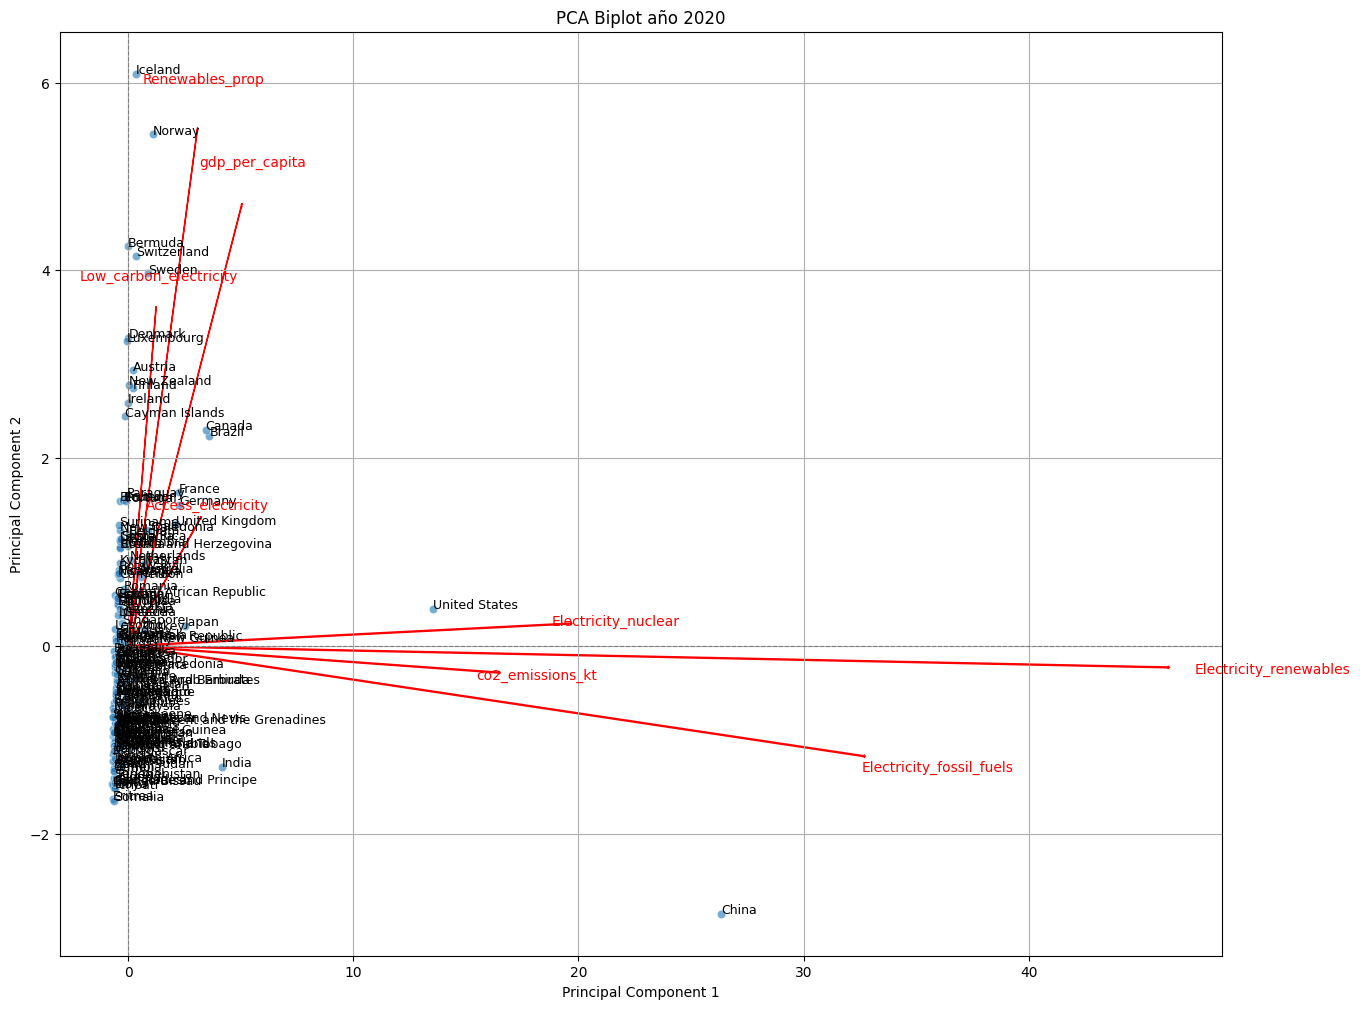

In [96]:
# Seleccionar datos estandarizados : excluir 'Entity' and 'Year'
df_2020_pca_data = df_2020.drop(['Entity', 'Year'], axis=1)


#Luego de estandarizar los datos seleccionamos los datos númericos para el PCA
# PCA n_components : 2
pca_2020_2_components = PCA(n_components=2)
principal_components_2020 = pca_2020_2_components.fit_transform(df_2020_pca_data)

# DataFrame con los primeros dos componentes para el 2020
df_pca_2020 = pd.DataFrame(data = principal_components_2020, columns = ['principal_component_1', 'principal_component_2'])

# Add 'Entity' back to the PCA dataframe for plotting (Year is constant for this data)
df_pca_2020 = pd.concat([df_2020['Entity'].reset_index(drop=True), df_pca_2020], axis=1)

# extraer loadings del PCA
loadings_2020 = pca_2020_2_components.components_.T * np.sqrt(pca_2020_2_components.explained_variance_)

# dataframe
df_loadings_2020 = pd.DataFrame(loadings_2020, columns=['PC1', 'PC2'], index=df_2020_pca_data.columns)

# biplot
plt.figure(figsize=(15, 12)) # Increased figure size for better label readability

# Scatter plot de puntos
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=df_pca_2020, alpha=0.6)

# entity labels
for i in range(df_pca_2020.shape[0]):
    plt.text(df_pca_2020['principal_component_1'][i], df_pca_2020['principal_component_2'][i],
             df_pca_2020['Entity'][i], fontsize=9)


# Plotear vectores
for i, var in enumerate(df_loadings_2020.index):
    plt.arrow(0, 0, df_loadings_2020.loc[var, 'PC1']*max(df_pca_2020['principal_component_1']),
              df_loadings_2020.loc[var, 'PC2']*max(df_pca_2020['principal_component_2']),
              color='red', width=0.01)
    plt.text(df_loadings_2020.loc[var, 'PC1']*max(df_pca_2020['principal_component_1'])*1.1,
             df_loadings_2020.loc[var, 'PC2']*max(df_pca_2020['principal_component_2'])*1.1,
             var, color='red', ha='center', va='center')

plt.title('PCA Biplot año 2020')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.show()

El biplot realizado, combina los puntos (países) con los vectores de las variables, permitiendo comprender con mayor detalle los patrones observados y analizar cómo se relacionan con las distintas variables. Los vectores representan el peso y la dirección de influencia de cada variable en el ordenamiento.

In [97]:
# Para una mejor compresión de los resultados del PCA extraemos los siguientes parámetros.

# Display
print(" Varianza explicada para componentes principales (2020):")
display(pca_2020_2_components.explained_variance_ratio_)

# Display
print("\nVarianza acumulada (2020):/n")
display(np.cumsum(pca_2020_2_components.explained_variance_ratio_))

# eigenvalues
eigenvalues_20 = pca_2020_2_components.explained_variance_

# eigenvectors
eigenvectors_20 = pca_2020_2_components.components_

# Display
print("\nEigenvalues- PCA 2020:")
display(pd.DataFrame(eigenvalues_20, columns=['Eigenvalue'], index=[f'PC{i+1}' for i in range(len(eigenvalues_20))]))

# Display
print("\nEigenvectors - PCA 2020:")
display(pd.DataFrame(eigenvectors_20, columns=df_2020_pca_data.columns, index=[f'PC{i+1}' for i in range(len(eigenvectors_20))]))

 Varianza explicada para componentes principales (2020):


array([0.54626557, 0.17806106])


Varianza acumulada (2020):/n


array([0.54626557, 0.72432663])


Eigenvalues- PCA 2020:


,Eigenvalue
PC1,5.631883
PC2,1.835772



Eigenvectors - PCA 2020:


,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita
PC1,0.051254,0.522977,0.314531,0.739093,0.019514,0.263548,0.048850,0.080339
PC2,0.164702,-0.142287,0.028882,-0.027715,0.432837,-0.034446,0.663863,0.567254


Resultados del PCA - 2020

El análisis de componentes principales (PCA) permitió reducir la dimensionalidad del conjunto de variables seleccionadas y visualizar patrones claros entre países.

En conjunto, los primeros dos componentes principales explicaron un 73% de la variabilidad de los datos.

Los resultados muestran que el primer componente (PC1) está fuertemente asociado a la electricidad generada a partir de renovables (0.73), seguida por la electricidad de origen fósil (0.52), la electricidad nuclear (0.31) y las emisiones de CO₂ (0.26).

El segundo componente (PC2), en cambio, se asocia de manera más marcada con variables como la proporción de renovables en el consumo final (0.66), PBI per cápita (0.567) y la electricidad de bajas emisiones de carbono (0.433).

Podemos observar que China y Estados Unidos se destacan por su posición aislada hacia la derecha del gráfico, por lo se caracteriza por matriz energética diversificada (nuclear, fósil, renovable) y altas emisiones de carbono.

 Los países como Islandia, Noruega y Suecia se ubican hacia la parte superior del gráfico, en la dirección de mayores pbi per capita y mayor proporción de energías limpias


* Aunque realizamos el PCA, con el objetivo de seleccionar variables, decidí dejar todas ya que todas explican en alguna dimensión parte de la varianza, esperando que permita una mayor diferenciación de grupos en el análisis de clasificación.

# K- MEANS (2020)

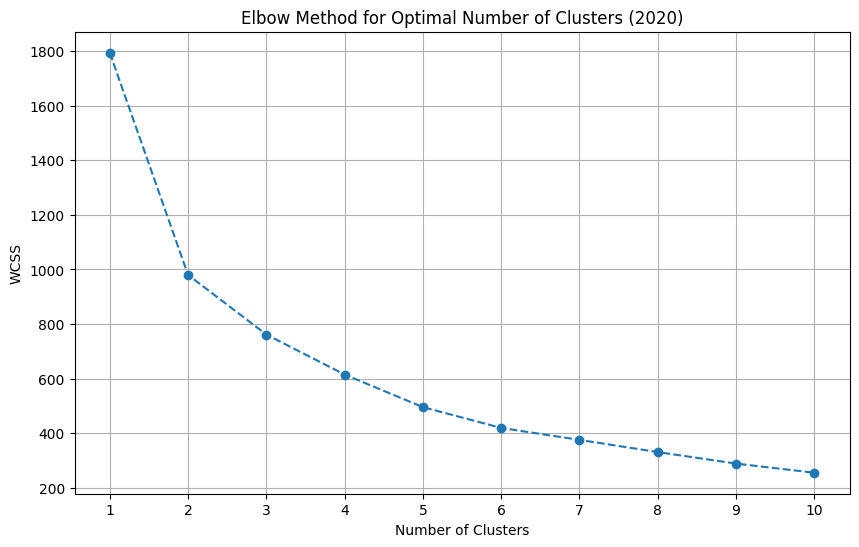

In [98]:
# Selección de datos para el clustering
X_2020 = df_2020.drop(['Entity', 'Year'], axis=1)

# Determinar el numero optimo de clusters con el Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_2020)
    wcss.append(kmeans.inertia_)

# Plot: Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters (2020)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)

In [99]:
# K-Means clustering con 5 clusters año 2020
kmeans_2020 = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans_2020.fit(X_2020)
clusters_2020 = kmeans_2020.predict(X_2020)
centers = kmeans_2020.cluster_centers_

# agregar cluster labels
X_2020['Cluster'] = clusters_2020

# agregar cluster labels
df_2020['Cluster'] = clusters_2020


# Display
print("DataFrame con cluster labels año 2020:")
display(X_2020)
display(X_2020.info())
display(X_2020.describe()) ## verifico max y min de la variable cluster

DataFrame con cluster labels año 2020:


,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita,Cluster
20,0.622583,-0.201417,-0.18341,-0.222361,1.402161,-0.196442,-0.958721,-0.645740,2
41,0.698356,-0.201763,-0.18341,-0.177897,1.839956,-0.145108,-0.958721,-0.401342,2
62,0.691903,0.005740,-0.18341,-0.221976,-1.049787,-0.075488,-0.939004,-0.501562,0
83,-1.051307,-0.188825,-0.18341,-0.112691,1.050042,-0.185385,-0.467272,-0.580660,2
104,0.698356,-0.200870,-0.18341,-0.228699,-0.901794,-0.112589,0.004461,0.050629,0
...,...,...,...,...,...,...,...,...,...
3564,0.698356,-0.055004,-0.18341,-0.180778,-0.817287,-0.123442,-0.759653,-0.581976,0
3585,-0.377833,-0.201619,-0.18341,-0.228699,-0.244784,-0.202341,-0.759653,-0.524132,0
3606,-0.166176,-0.193867,-0.18341,-0.224185,-0.635915,-0.200358,-0.759653,-0.648650,0
3627,-1.129258,-0.196000,-0.18341,-0.103087,1.453382,-0.188806,-0.759653,-0.621537,2


<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 20 to 3648
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Access_electricity        175 non-null    float64
 1   Electricity_fossil_fuels  175 non-null    float64
 2   Electricity_nuclear       175 non-null    float64
 3   Electricity_renewables    175 non-null    float64
 4   Low_carbon_electricity    175 non-null    float64
 5   co2_emissions_kt          175 non-null    float64
 6   Renewables_prop           175 non-null    float64
 7   gdp_per_capita            175 non-null    float64
 8   Cluster                   175 non-null    int32  
dtypes: float64(8), int32(1)
memory usage: 13.0 KB


None

,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita,Cluster
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,0.219345,0.034862,-0.004522,0.153734,0.119756,-0.007157,0.100441,0.077397,1.177143
std,0.809402,1.278158,0.996612,1.780921,0.979452,0.712588,1.099186,1.086618,1.429389
min,-2.357532,-0.201763,-0.183410,-0.228891,-1.078681,-0.202493,-0.962434,-0.660093,0.000000
25%,-0.139462,-0.200553,-0.183410,-0.226874,-0.757708,-0.195265,-0.731246,-0.573409,0.000000
50%,0.698356,-0.191965,-0.183410,-0.201041,-0.071232,-0.169272,-0.199407,-0.401342,0.000000
75%,0.698356,-0.115531,-0.183410,-0.089547,0.867990,-0.084162,0.649462,0.132635,2.000000
max,0.698356,14.736746,10.823157,20.753801,1.839956,7.104479,6.035004,5.322592,4.000000


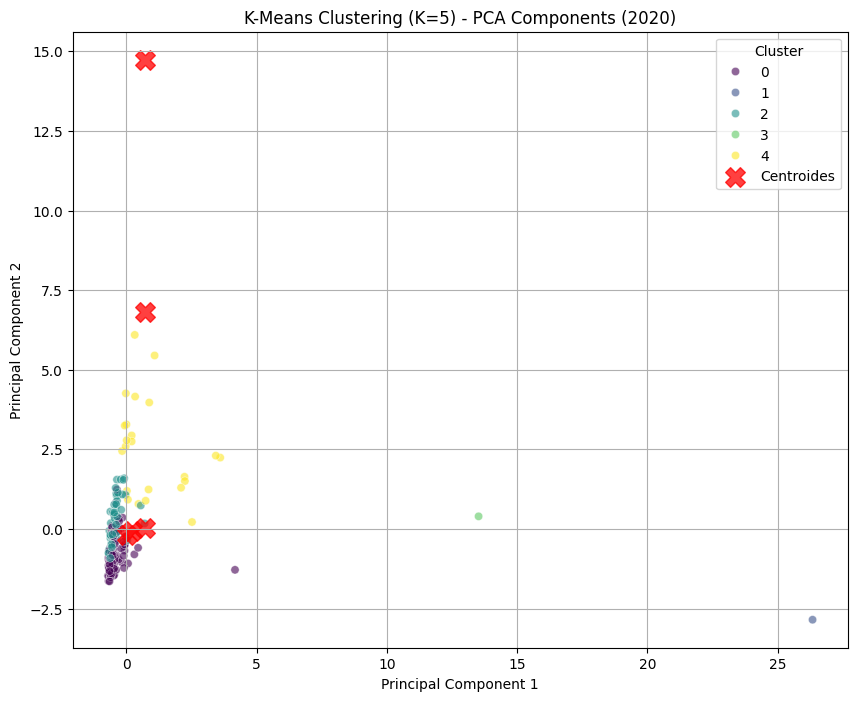

In [100]:
# Agrego cluster labels para graficar
df_pca_2020['Cluster'] = clusters_2020

# gráfico
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster', data=df_pca_2020, palette='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroides') # Plot centroids
plt.title('K-Means Clustering (K=5) - PCA Components (2020)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [101]:
# agrupar el dataframe por 'Cluster' y hacer una  lista de los paises en cada cluster
countries_per_cluster = df_2020.groupby('Cluster')['Entity'].unique()

# Display
for cluster_label, countries_list in countries_per_cluster.items():
    print(f"Cluster {cluster_label}:")
    print(countries_list)
    print("-" * 30)

Cluster 0:
['Algeria' 'Antigua and Barbuda' 'Argentina' 'Aruba' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belize' 'Benin'
 'Botswana' 'Burkina Faso' 'Chad' 'Comoros' 'Congo' 'Cuba' 'Cyprus'
 'Czechia' 'Djibouti' 'Dominica' 'Dominican Republic' 'Egypt'
 'Equatorial Guinea' 'Eritrea' 'Gabon' 'Gambia' 'Ghana' 'Greece' 'Grenada'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'India' 'Indonesia' 'Iraq'
 'Israel' 'Jamaica' 'Jordan' 'Kazakhstan' 'Kiribati' 'Kuwait' 'Lebanon'
 'Libya' 'Madagascar' 'Malaysia' 'Maldives' 'Mali' 'Malta' 'Mauritania'
 'Mauritius' 'Mexico' 'Mongolia' 'Montenegro' 'Morocco' 'Myanmar' 'Nauru'
 'New Caledonia' 'Niger' 'Nigeria' 'North Macedonia' 'Oman' 'Pakistan'
 'Papua New Guinea' 'Philippines' 'Poland' 'Puerto Rico' 'Qatar'
 'Saint Kitts and Nevis' 'Saint Lucia' 'Saint Vincent and the Grenadines'
 'Samoa' 'Sao Tome and Principe' 'Saudi Arabia' 'Senegal' 'Serbia'
 'Seychelles' 'Singapore' 'Solomon Islands' 'Somalia' 'South Africa'
 'South Su


Conclusiones generales del k-means clustering para el año 2020


Aunque el método Elbow podría haber sugerido un número óptimo de clústeres diferente, el uso de 5 clústeres resultó eficaz para separar los países con características únicas o lo que podrían definirse como outliers. El algoritmo aisló con éxito a China y Estados Unidos en sus propios clústeres distintos. Resaltando características energéticas y niveles de emisión de carbono significativamente diferentes en comparación con la mayoría de los demás países, que se agruparon en clústeres más grandes.

Una posible caracterización de los clusters resultantes:

Cluster 0 → Grupo heterogéneo de países intermedios, aún dependientes de fósiles.

Clusters 1 y 3 → Outliers globales (China y EE.UU.).

Cluster 2 → Países en desarrollo con fuerte presencia de renovables.

Cluster 4 → Países desarrollados y líderes en transición energética.





# **Validación del modelo**





In [102]:

# Calcular el Silhouette Score
silhouette_avg = silhouette_score(X_2020, clusters_2020)
print(f"Silhouette Score for K-Means with 5 clusters (2020): {silhouette_avg}")

# Calcular el  Davies-Bouldin Index
davies_bouldin_avg = davies_bouldin_score(X_2020, clusters_2020)
print(f"Davies-Bouldin Index for K-Means with 5 clusters (2020): {davies_bouldin_avg}")

Silhouette Score for K-Means with 5 clusters (2020): 0.4168035994976344
Davies-Bouldin Index for K-Means with 5 clusters (2020): 0.6880158369175007


**Silhouette Score** = 0.33 sugiere que los clusters existen y son distinguibles, pero hay zonas de solapamiento entre ellos. Es decir, no todos los países se diferencian de forma estricta.

**Davies–Bouldin Index**  = 0.75 sugiere una separación grupos aceptable.

Las métricas de validación indican que el modelo de 5 clusters en 2020 es aceptable: existen grupos en función de las variables definidas y se han diferenciado.



## **Análisis de datos para el año 2000**

In [103]:
# Filtrar el dataframe por año
df_2000 = df4[df4['Year'] == 2000].copy()

# Display
print("Data año 2000:")
display(df_2000.head())

# Display the info of the filtered dataframe
display(df_2000.info())

Data año 2000:


,Entity,Year,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita
0,Afghanistan,2000,-2.542935,-0.201302,-0.18341,-0.225914,0.846378,-0.201689,-0.958721,-0.663171
21,Albania,2000,0.698356,-0.201359,-0.18341,-0.185196,1.752833,-0.198418,-0.958721,-0.614222
42,Algeria,2000,0.664525,-0.133066,-0.18341,-0.228411,-1.072572,-0.094052,-0.958721,-0.581236
63,Angola,2000,-1.798417,-0.200322,-0.18341,-0.220248,0.797586,-0.180729,-0.916541,-0.643669
84,Antigua and Barbuda,2000,0.622229,-0.201359,-0.18341,-0.228891,-1.078681,-0.202273,-0.444808,-0.110619


<class 'pandas.core.frame.DataFrame'>
Index: 173 entries, 0 to 3628
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    173 non-null    object 
 1   Year                      173 non-null    int64  
 2   Access_electricity        173 non-null    float64
 3   Electricity_fossil_fuels  173 non-null    float64
 4   Electricity_nuclear       173 non-null    float64
 5   Electricity_renewables    173 non-null    float64
 6   Low_carbon_electricity    173 non-null    float64
 7   co2_emissions_kt          173 non-null    float64
 8   Renewables_prop           173 non-null    float64
 9   gdp_per_capita            173 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 14.9+ KB


None

# PCA - 2000

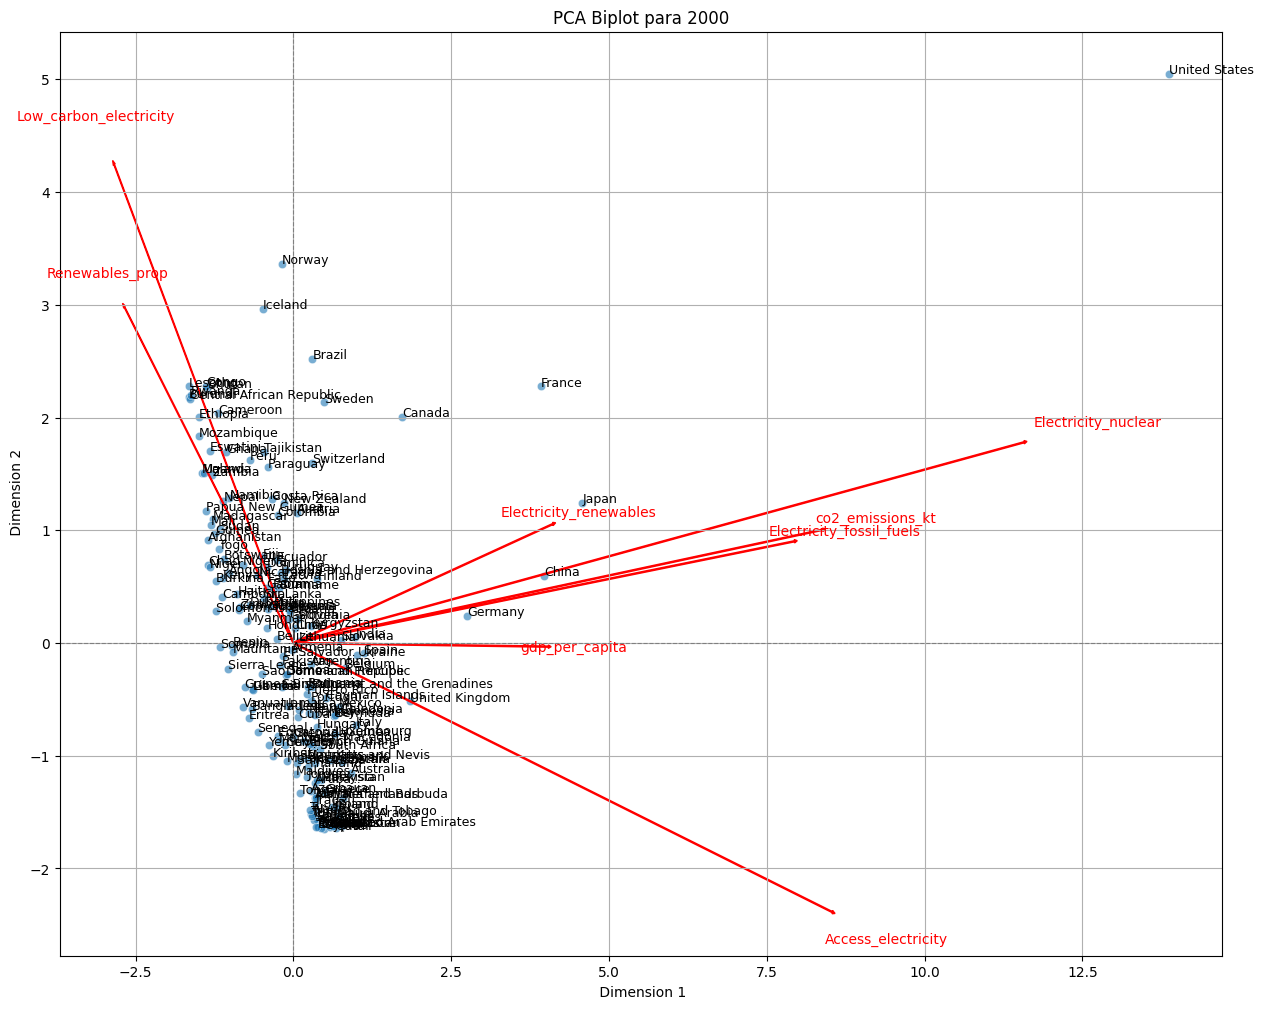

In [104]:
# Seleccionar los datos estandarizados, numéricos para el pca del dataframe del 2000
# Excluir 'Entity' and 'Year'
df_2000_pca_data = df_2000.drop(['Entity', 'Year'], axis=1)

# PCA y los dos primeros componentes
pca_2000_2_components = PCA(n_components=2)
principal_components_2000 = pca_2000_2_components.fit_transform(df_2000_pca_data)

# Crear un datafreame con los dos primeros componentes
df_pca_2000 = pd.DataFrame(data = principal_components_2000, columns = ['principal_component_1', 'principal_component_2'])

# Volver a agregar 'Entity' , el año ya es una constante
df_pca_2000 = pd.concat([df_2000['Entity'].reset_index(drop=True), df_pca_2000], axis=1)

# Extraer los loadings para los componentes
vec_2000 = pca_2000_2_components.components_.T * np.sqrt(pca_2000_2_components.explained_variance_)

# Crear el dataframe para los loadings del 2000 Create a DataFrame for the 2019 loadings
df_vec_2000 = pd.DataFrame(vec_2000, columns=['PC1', 'PC2'], index=df_2000_pca_data.columns)

# Crear el biplot para el 2000
plt.figure(figsize=(15, 12))

# Scatter plot paises en el 2000
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=df_pca_2000, alpha=0.6)

# Agregar text labels para cada pais
for i in range(df_pca_2000.shape[0]):
    plt.text(df_pca_2000['principal_component_1'][i], df_pca_2000['principal_component_2'][i],
             df_pca_2000['Entity'][i], fontsize=9)


# Plotear vectores
for i, var in enumerate(df_vec_2000.index):
    plt.arrow(0, 0, df_vec_2000.loc[var, 'PC1']*max(df_pca_2000['principal_component_1']),
              df_vec_2000.loc[var, 'PC2']*max(df_pca_2000['principal_component_2']),
              color='red', width=0.01)
    plt.text(df_vec_2000.loc[var, 'PC1']*max(df_pca_2000['principal_component_1'])*1.1,
             df_vec_2000.loc[var, 'PC2']*max(df_pca_2000['principal_component_2'])*1.1,
             var, color='red', ha='center', va='center')

plt.title('PCA Biplot para 2000')
plt.xlabel(' Dimension 1')
plt.ylabel(' Dimension 2')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.show()

In [105]:
# Para una mejor compresión de los resultados del PCA extraemos los siguientes parámetros.

# Display
print(" Varianza explicada para componentes principales (2000):")
display(pca_2000_2_components.explained_variance_ratio_)

# Display
print("\nVarianza acumulada (2000):/n")
display(np.cumsum(pca_2000_2_components.explained_variance_ratio_))
# eigenvalues
eigenvalues = pca_2000_2_components.explained_variance_

# eigenvectors
eigenvectors = pca_2000_2_components.components_

# Display eigenvalues
print("\nEigenvalues- PCA 2000:")
display(pd.DataFrame(eigenvalues, columns=['Eigenvalue'], index=[f'PC{i+1}' for i in range(len(eigenvalues))])) #desmenuzar para entender

# Display eigenvectors como DataFrame
print("\nEigenvectors (Principal Components) - PCA 2000:")
display(pd.DataFrame(eigenvectors, columns=df_2000_pca_data.columns, index=[f'PC{i+1}' for i in range(len(eigenvectors))])) #desmenuzar para entender

 Varianza explicada para componentes principales (2000):


array([0.34176283, 0.25700749])


Varianza acumulada (2000):/n


array([0.34176283, 0.59877032])


Eigenvalues- PCA 2000:


,Eigenvalue
PC1,2.017757
PC2,1.517364



Eigenvectors (Principal Components) - PCA 2000:


,Access_electricity,Electricity_fossil_fuels,Electricity_nuclear,Electricity_renewables,Low_carbon_electricity,co2_emissions_kt,Renewables_prop,gdp_per_capita
PC1,0.433067,0.402617,0.587247,0.208491,-0.144041,0.425293,-0.135803,0.204844
PC2,-0.383734,0.145034,0.286296,0.169662,0.682163,0.161473,0.479078,-0.005191


Resultados del PCA - 2000
En conjunto, los primeros dos componentes principales explicaron un 60% de la variabilidad de los datos.

Los resultados muestran que el primer componente (PC1) está fuertemente asociado las variables Electricity_fossil_fuels, Electricity_nuclear, Electricity_renewables, co2_emissions_kt y gdp_per_capita.

El segundo componente (PC2), en cambio, se asocia a variables como Access_electricity, Renewables_prop y Low_carbon_electricity.

Estados Unidos aparece claramente separado hacia la derecha y arriba, reflejando su alto nivel de generación total y presencia de energia nuclear.

China y Alemania también se destacan hacia valores altos de PC1.

Países como Noruega, Islandia y Brasil se orientan hacia arriba en PC2, asociados con una mayor proporción de renovables y bajas emisiones.

La mayoría de los países queda concentrada cerca del origen, lo que refleja perfiles más intermedios.



# K- MEANS (2000)

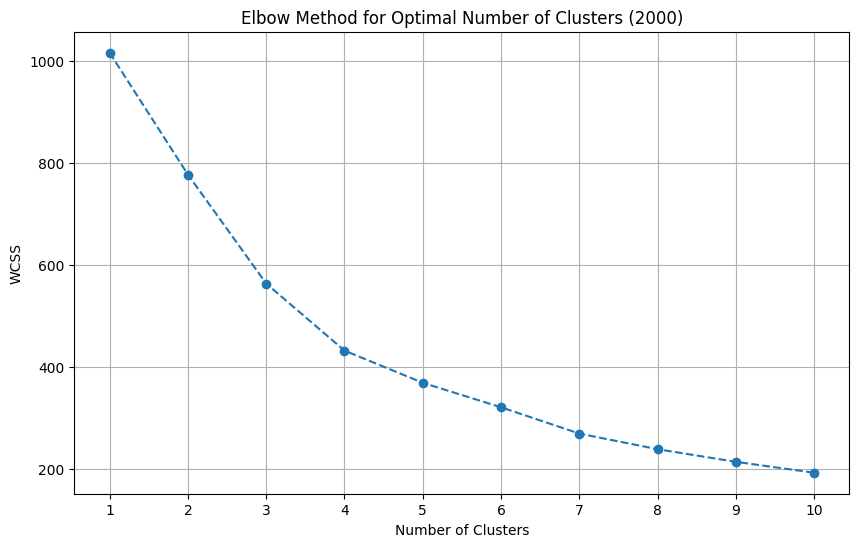

In [106]:
# Seleccionar los datos para el clustering (datos estandarizados sin columnas entity y Year)
X_2000 = df_2000.drop(['Entity', 'Year'], axis=1)

# determinar número óptimo de clusters Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_2000)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters (2000)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

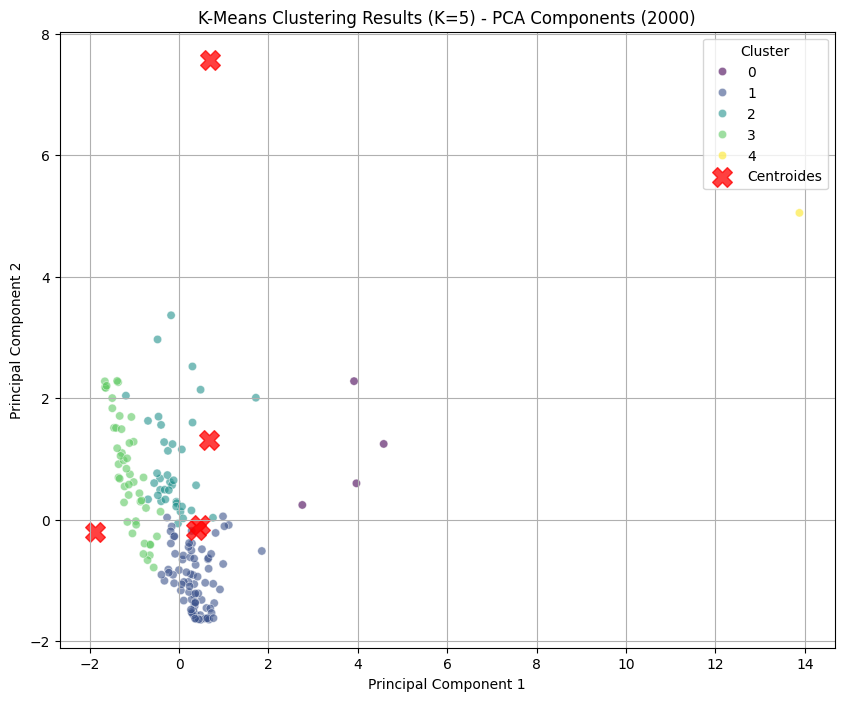

In [107]:
# K-Means clustering con 4 clusters año 2000
kmeans_2000 = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans_2000.fit(X_2000)
clusters_2000 = kmeans_2000.predict(X_2000)
centers_2000 = kmeans_2000.cluster_centers_

# Agregar cluster labels
df_2000['Cluster'] = clusters_2000

# Agregar cluster labels
df_pca_2000['Cluster'] = clusters_2000

# graficar
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster', data=df_pca_2000, palette='viridis', alpha=0.6)
plt.scatter(centers_2000[:, 0], centers_2000[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroides') # Plot centroids
plt.title('K-Means Clustering Results (K=5) - PCA Components (2000)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [108]:
# agrupar datos por 'Cluster' y hacer una lista de paises por cluster
countries_per_cluster = df_2000.groupby('Cluster')['Entity'].unique()

# Display the list of countries for each cluster
for cluster_label, countries_list in countries_per_cluster.items():
    print(f"Cluster {cluster_label}:")
    print(countries_list)
    print("-" * 30)

Cluster 0:
['China' 'France' 'Germany' 'Japan']
------------------------------
Cluster 1:
['Algeria' 'Antigua and Barbuda' 'Argentina' 'Aruba' 'Australia'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Bermuda' 'Bulgaria' 'Cayman Islands' 'Cuba' 'Cyprus' 'Czechia' 'Denmark'
 'Dominican Republic' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Estonia'
 'French Guiana' 'Greece' 'Grenada' 'Guyana' 'Hungary' 'India' 'Indonesia'
 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Jordan' 'Kazakhstan'
 'Kiribati' 'Kuwait' 'Lebanon' 'Libya' 'Luxembourg' 'Malaysia' 'Maldives'
 'Malta' 'Mauritius' 'Mexico' 'Mongolia' 'Morocco' 'Nauru' 'Netherlands'
 'New Caledonia' 'North Macedonia' 'Oman' 'Pakistan' 'Poland' 'Portugal'
 'Puerto Rico' 'Qatar' 'Romania' 'Saint Kitts and Nevis' 'Saint Lucia'
 'Saint Vincent and the Grenadines' 'Samoa' 'Saudi Arabia' 'Seychelles'
 'Singapore' 'South Africa' 'Spain' 'Thailand' 'Tonga'
 'Trinidad and Tobago' 'Tunisia' 'Turkey' 'Turkmenistan' 'Tuva

In [109]:
# Calculate the Silhouette Score
silhouette_avg = silhouette_score(X_2000, clusters_2000)
print(f"Silhouette Score for K-Means with 5 clusters (2020): {silhouette_avg}")

# Calculate the Davies-Bouldin Index
davies_bouldin_avg = davies_bouldin_score(X_2000, clusters_2000)
print(f"Davies-Bouldin Index for K-Means with 5 clusters (2020): {davies_bouldin_avg}")

Silhouette Score for K-Means with 5 clusters (2020): 0.35953231070858094
Davies-Bouldin Index for K-Means with 5 clusters (2020): 0.922776216932431


Nuevamente ambas métricas, **Silhouette Score** = 0.36 y **Davies–Bouldin Index**  = 0.92 sugieren una separación grupos aceptable.







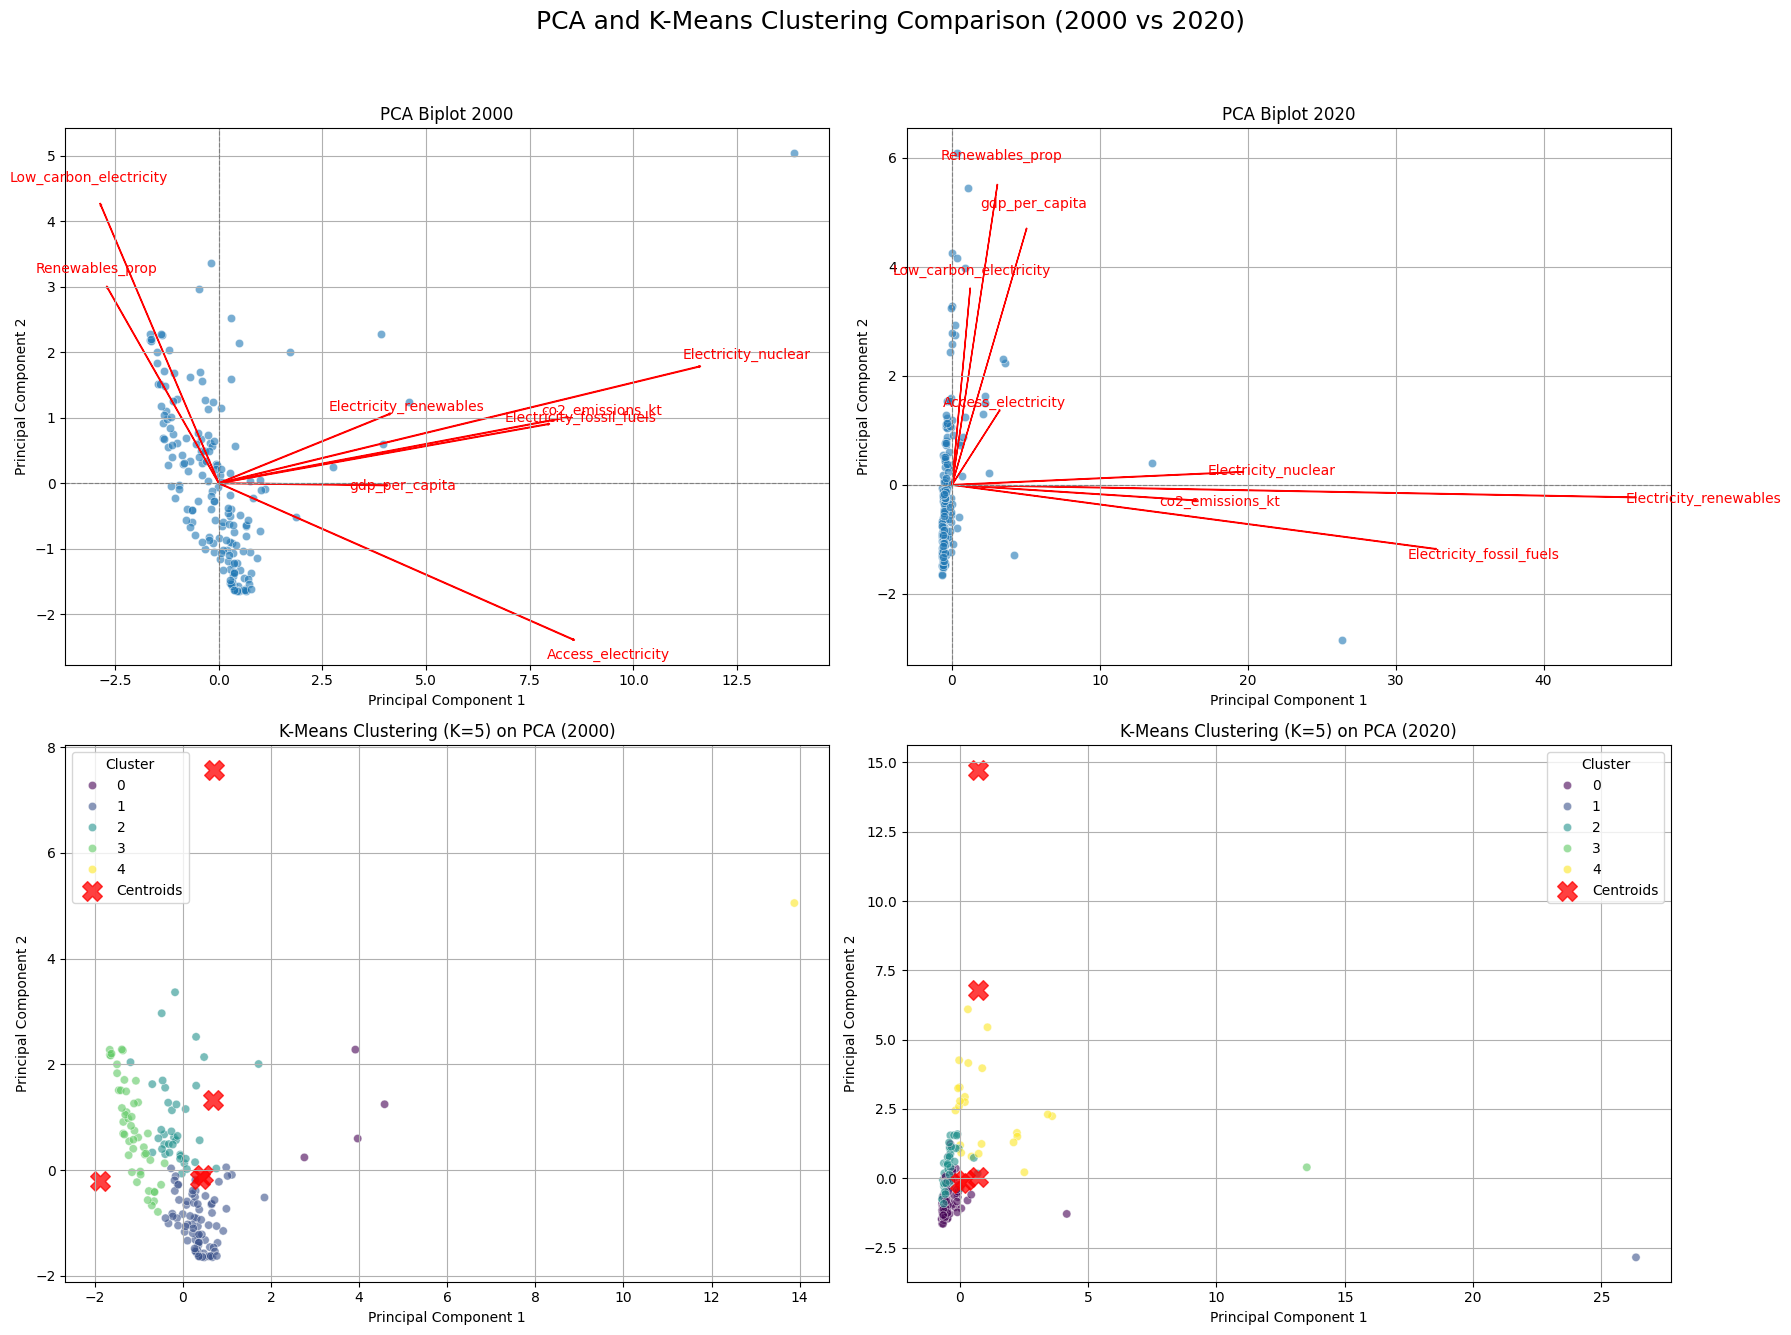

In [110]:
# 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('PCA and K-Means Clustering Comparison (2000 vs 2020)', fontsize=18)

# Plot PCA 2000 con vectores
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=df_pca_2000, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('PCA Biplot 2000')
axes[0, 0].set_xlabel('Principal Component 1')
axes[0, 0].set_ylabel('Principal Component 2')
axes[0, 0].grid(True)
# agregar variable vectors para el 2000
for i, var in enumerate(df_vec_2000.index):
    axes[0, 0].arrow(0, 0, df_vec_2000.loc[var, 'PC1'] * max(df_pca_2000['principal_component_1']),
                     df_vec_2000.loc[var, 'PC2'] * max(df_pca_2000['principal_component_2']),
                     color='red', width=0.01)
    axes[0, 0].text(df_vec_2000.loc[var, 'PC1'] * max(df_pca_2000['principal_component_1']) * 1.1,
                    df_vec_2000.loc[var, 'PC2'] * max(df_pca_2000['principal_component_2']) * 1.1,
                    var, color='red', ha='center', va='center')
axes[0, 0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0, 0].axvline(0, color='grey', linestyle='--', linewidth=0.8)


# Plot PCA 2020 con vectors
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=df_pca_2020, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('PCA Biplot 2020')
axes[0, 1].set_xlabel('Principal Component 1')
axes[0, 1].set_ylabel('Principal Component 2')
axes[0, 1].grid(True)
# agregar variable vectors para 2020
for i, var in enumerate(df_loadings_2020.index):
    axes[0, 1].arrow(0, 0, df_loadings_2020.loc[var, 'PC1'] * max(df_pca_2020['principal_component_1']),
                     df_loadings_2020.loc[var, 'PC2'] * max(df_pca_2020['principal_component_2']),
                     color='red', width=0.01)
    axes[0, 1].text(df_loadings_2020.loc[var, 'PC1'] * max(df_pca_2020['principal_component_1']) * 1.1,
                    df_loadings_2020.loc[var, 'PC2'] * max(df_pca_2020['principal_component_2']) * 1.1,
                    var, color='red', ha='center', va='center')
axes[0, 1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0, 1].axvline(0, color='grey', linestyle='--', linewidth=0.8)


# Plot K-Means 2000
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster', data=df_pca_2000, palette='viridis', alpha=0.6, ax=axes[1, 0])
axes[1, 0].scatter(centers_2000[:, 0], centers_2000[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
axes[1, 0].set_title('K-Means Clustering (K=5) on PCA (2000)')
axes[1, 0].set_xlabel('Principal Component 1')
axes[1, 0].set_ylabel('Principal Component 2')
axes[1, 0].legend(title='Cluster')
axes[1, 0].grid(True)

# Plot K-Means 2020
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster', data=df_pca_2020, palette='viridis', alpha=0.6, ax=axes[1, 1])
axes[1, 1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
axes[1, 1].set_title('K-Means Clustering (K=5) on PCA (2020)')
axes[1, 1].set_xlabel('Principal Component 1')
axes[1, 1].set_ylabel('Principal Component 2')
axes[1, 1].legend(title='Cluster')
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Basándonos en el análisis exploratorio de datos, el PCA y el agrupamiento K-Means realizados sobre el conjunto de datos «Global Data on Sustainable Energy» para los años 2000 y 2020, podemos extraer las siguientes conclusiones respectos al objetivo y las hipótesis planteadas.

El objetivo principal era identificar patrones y perfiles energéticos entre los países utilizando un conjunto reducido de variables clave energéticas, socioeconómicas y medioambientales. Mediante el uso del PCA y la clasificación no supervisdada, K-Means, se lograron identificar patrones y agrupamientos de países basados en las variables seleccionadas tanto en 2000 como en 2020. A partir de los gráficos realizados se observó que los países no forman un grupo único y homogéneo. Por lo tanto, hay evidencias suficiente para rechazar la hipótesis nula (H0) y aceptar la hipótesis alternativa (H1). Los resultados de la agrupación demuestran que existen diferencias significativas en los perfiles energéticos entre los países, y que estas diferencias permiten identificar agrupaciones coherentes.

Conclusiones comparativas

El análisis conjunto de los PCA y los K-Means para 2000 y 2020 muestra la existencia de patrones distintos entre ambos años, lo que refleja los cambios en los perfiles energéticos y socioeconómicos de los países en las últimas dos décadas.

En ambos años, países como China y Estados Unidos se distinguen claramente como outliers, con perfiles marcados debido a sus sistemas energéticos y elevados niveles de emisiones. El resto de los países tiende a distribuirse a lo largo de un gradiente ya que el agrupamiento no genera “islas” completamente aisladas, sino que parece seguir un gradiente de desarrollo socioeconómico y transición energética.

La comparación temporal permite apreciar transiciones energéticas: países que en 2000 compartían cluster de un perfil intermedio, en 2020 pasaron a agruparse con paises de mayores ingresos y mayor proporción de renovables. Un ejemplo es Brasil, que en el año 2000 se encontraba en un cluster con varios países latinoamericanos y de Europa del Este (Cluster 2), mientras que en 2020 aparece en un grupo más cercano a economías desarrolladas como Canadá, Alemania, Suecia o Noruega (Cluster 3).

En síntesis, los resultados sugieren que entre 2000 y 2020 algunos países migraron hacia clusters más asociados con la transición energética, mientras que las grandes potencias se mantuvieron perfiles diferenciados y más estables en el tiempo.




